## 1. Importing the libraries

In [219]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score, precision_recall_curve, average_precision_score, roc_curve, auc

from xgboost import XGBClassifier

## 2. Configurations to use in the file

In [205]:
# Dataset Configuration
DATASET_PATH = "./HR-Employee-Attrition.csv"
TARGET_COLUMN = "Attrition"

# Train test split configuration
RANDOM_STATE = 42
TEST_SIZE = 0.2



# Model configuration
XGB_PARAMS = {
    "learning_rate": 0.1,
    "n_estimators": 300,
    "max_depth": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE
}

# Visualization configuration
ALPHA = 0.5
FIGURE_SIZE = (10,10)
FEATURE_IMPORTANCE_TOP_N = 15

## 3. Helper functions

In [189]:
def evaluate_model(prediction, prediction_probability, test_set):
    print("Accuracy score: ", accuracy_score(test_set, prediction))

    print("\n ROC AUC score: ", roc_auc_score(test_set, prediction_probability))

    cm = confusion_matrix(test_set, prediction)
    print("\n Confusion matrix: \n", cm)

    print("\n Classification report: \n", classification_report(test_set, prediction))
    

In [154]:
def plot_feature_importance(ml_model, training_set):
    # Extracting the values from model and training set
    importances = ml_model.feature_importances_
    feature_names = training_set.columns

    # creating a dataframe from the extracted values
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    # Plotting the importance plot
    plt.figure(figsize=FIGURE_SIZE)
    sns.barplot(
        x="Importance",
        y="Feature",
        data=importance_df,
        hue="Feature",
        palette="magma",
        legend=False
    )

    plt.title('Feature Importance for Employee Attrition', fontsize=14, pad=15)
    plt.xlabel('Relative Importance (Contribution to Prediction)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=ALPHA)

    plt.tight_layout()
    plt.show()

In [220]:
def plot_roc_curve(test_set, probabilities):

    # Step 1: Compute ROC curve data points
    fpr, tpr, _ = roc_curve(test_set, probabilities)
    roc_auc = auc(fpr, tpr)

    # Step 2: Plot the ROC Curve
    plt.figure(figsize=FIGURE_SIZE)
    plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'XGBoost ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='darkgrey', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
    plt.title('XGBoost Classifier: ROC Curve', fontsize=13, pad=15)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=':', alpha=ALPHA)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_predictions(test_set, prediction_probability):

    # Step 1: Compute Precision-Recall data points
    precision, recall, _ = precision_recall_curve(test_set, prediction_probability)
    avg_precision = average_precision_score(test_set, prediction_probability)

    # Step 2: Calculate baseline (percentage of positive cases in the dataset)
    baseline = sum(test_set) / len(test_set)

    # Step 3: Plot the PR Curve
    plt.figure(figsize=FIGURE_SIZE)
    plt.plot(recall, precision, color='#2ca02c', lw=2.5, label=f'XGBoost PR (AP = {avg_precision:.3f})')
    plt.axhline(y=baseline, color='darkgrey', lw=1.5, linestyle='--', label=f'Baseline (Rate = {baseline:.3f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall (Sensitivity)', fontsize=11)
    plt.ylabel('Precision (Positive Predictive Value)', fontsize=11)
    plt.title('XGBoost Classifier: Precision-Recall Curve', fontsize=13, pad=15)
    plt.legend(loc="lower left")
    plt.grid(True, linestyle=':', alpha=ALPHA)

    plt.tight_layout()
    plt.show()

In [156]:
def display_prediction_examples(ml_model, data_frame):
    prediction = ml_model.predict(data_frame)
    print("Predicted Attrition: ", prediction)

## 4. Loading the dataset

In [157]:
df = pd.read_csv(DATASET_PATH)

## 5. Understanding the dataset / Dataset overview

In [158]:
df.shape

(1470, 35)

In [159]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [160]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [161]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [162]:
df.duplicated().sum()

np.int64(0)

In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [164]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 6. Defining the feature list

In [165]:
NUMERICAL_COLUMNS = df.select_dtypes(include='number')

CATEGORICAL_COLUMNS = df.select_dtypes(include="str")

target_column = TARGET_COLUMN

LABEL_ENCODE_COLUMNS = ["Attrition", "Gender", "Over18", "OverTime"]

ONEHOT_ENCODE_COLUMNS = ["Department", "EducationField", "JobRole", "MaritalStatus", "BusinessTravel"]


## 7. Outlier Analysis

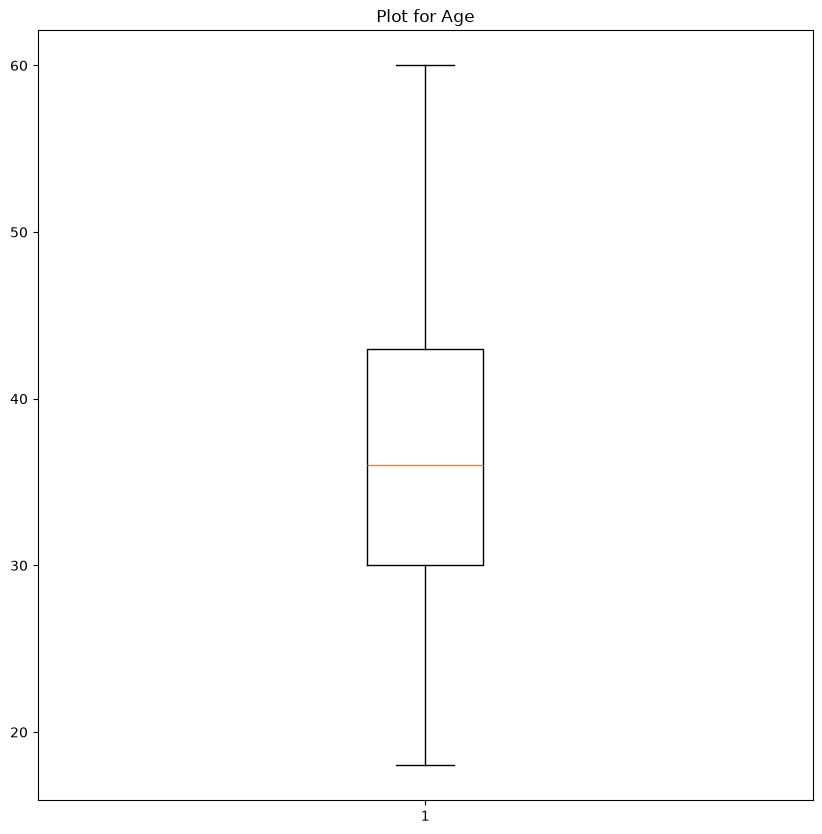

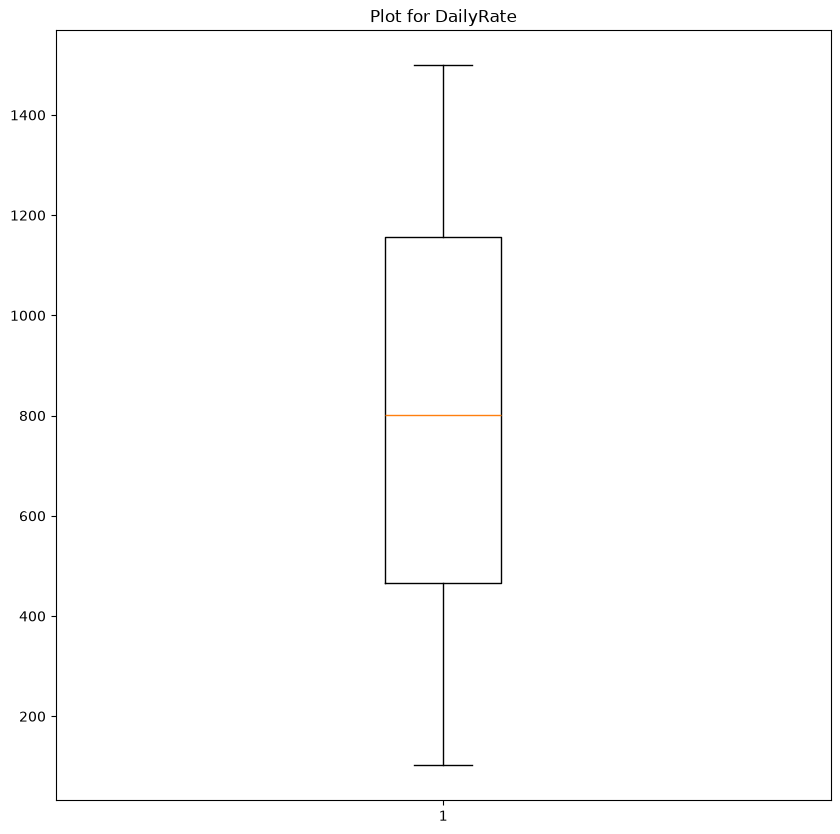

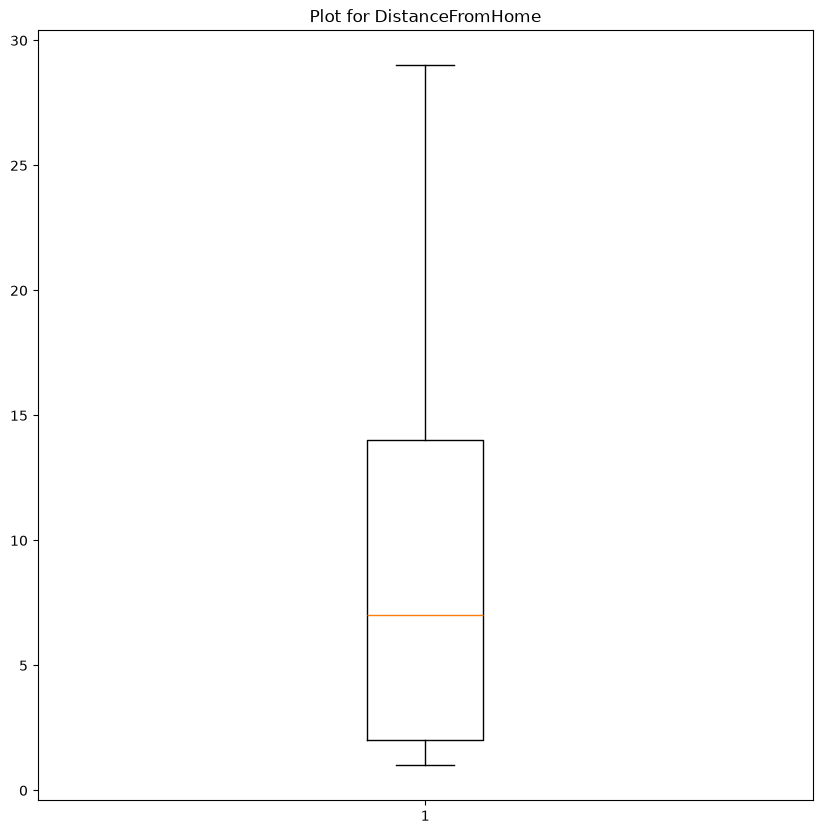

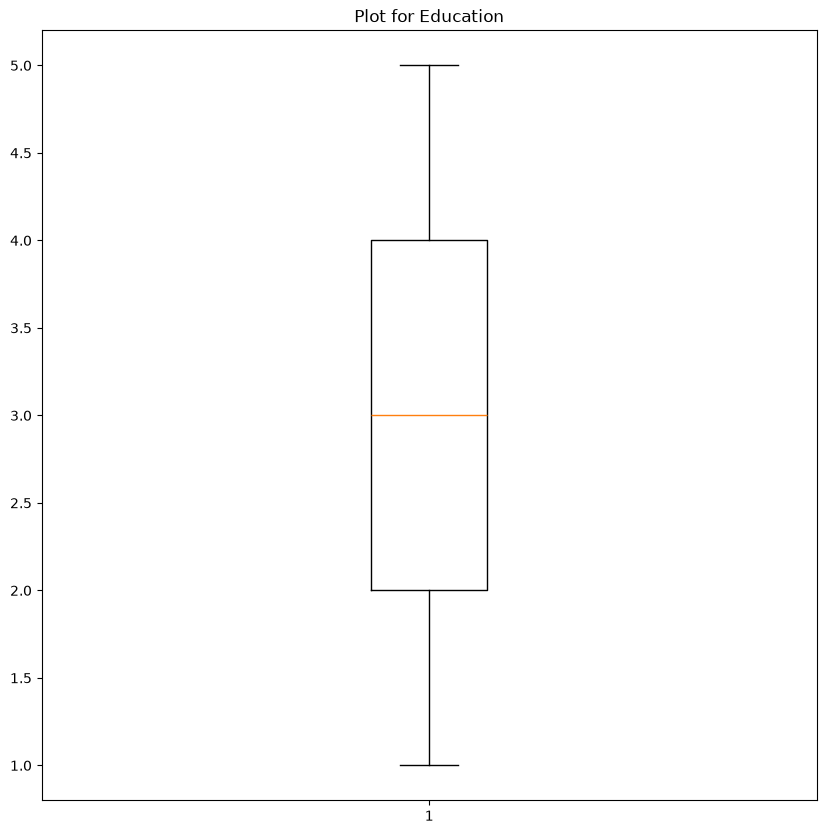

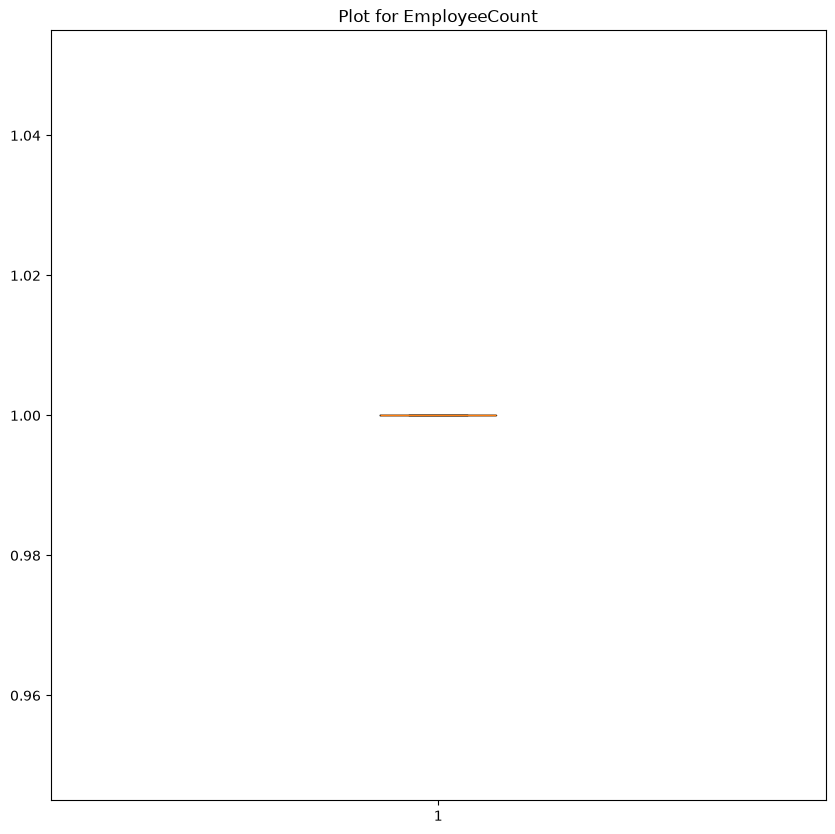

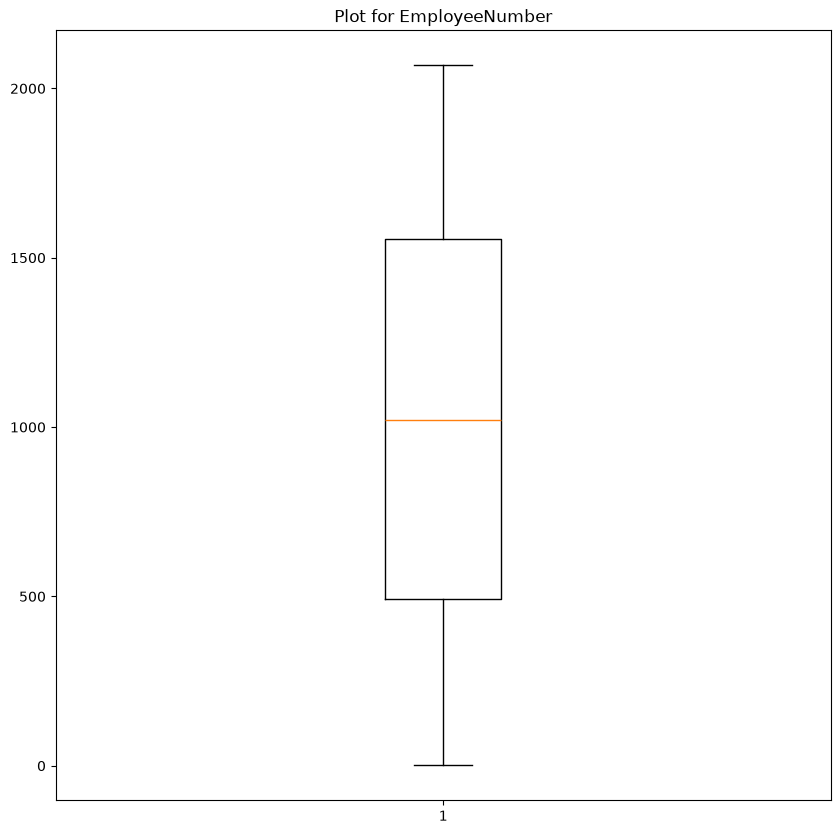

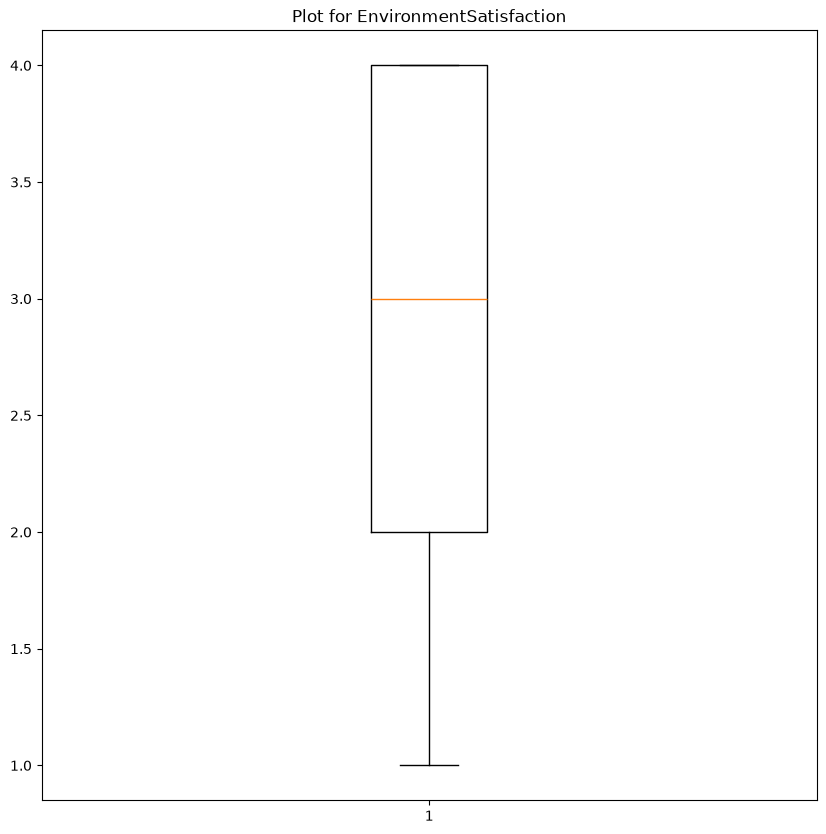

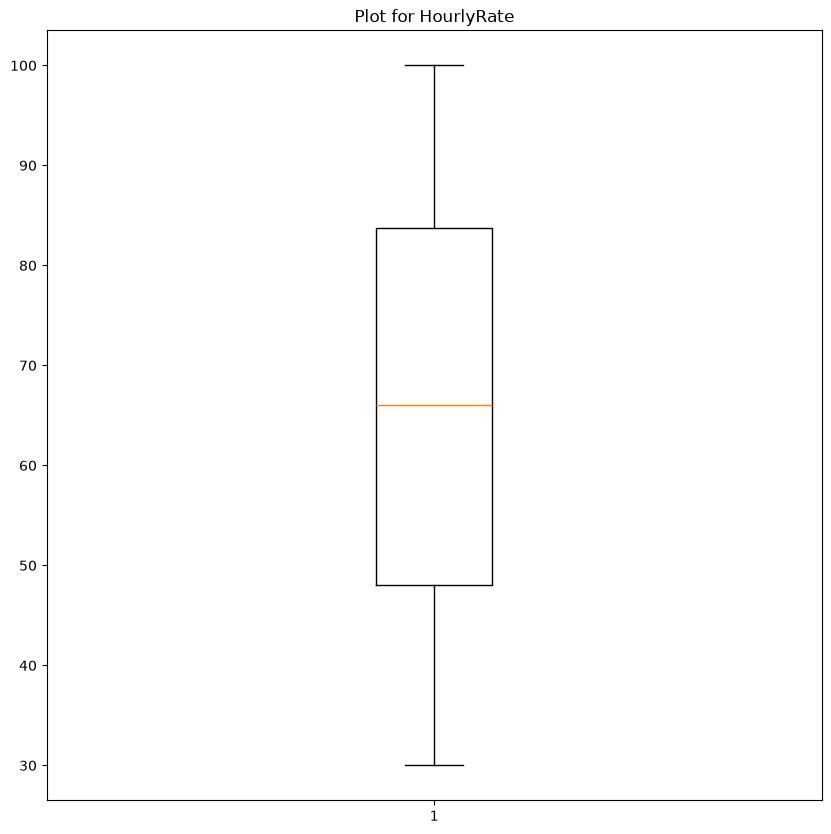

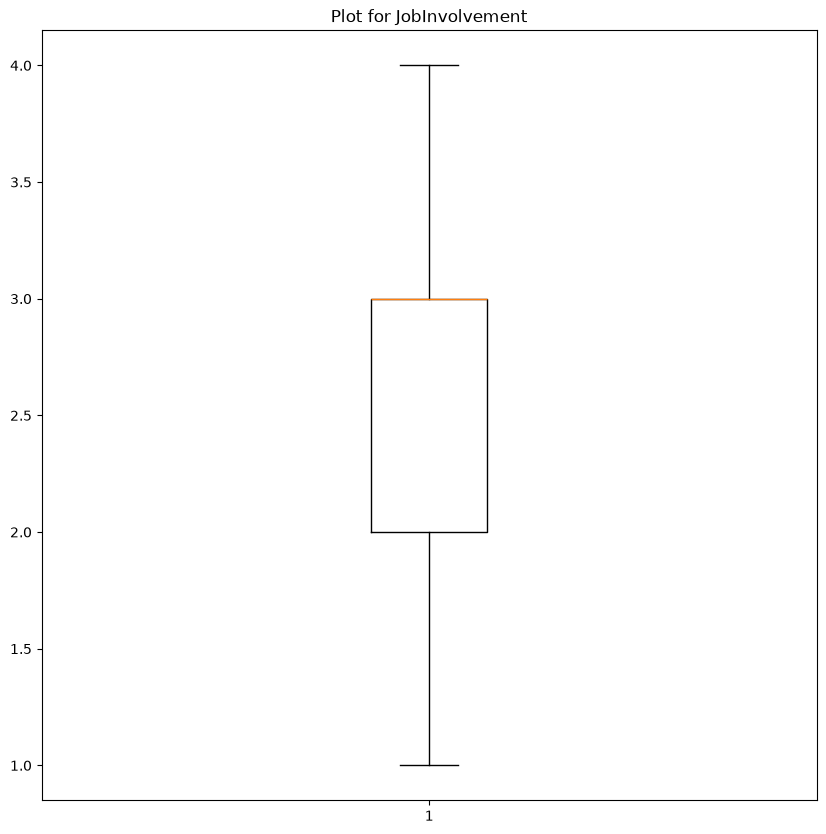

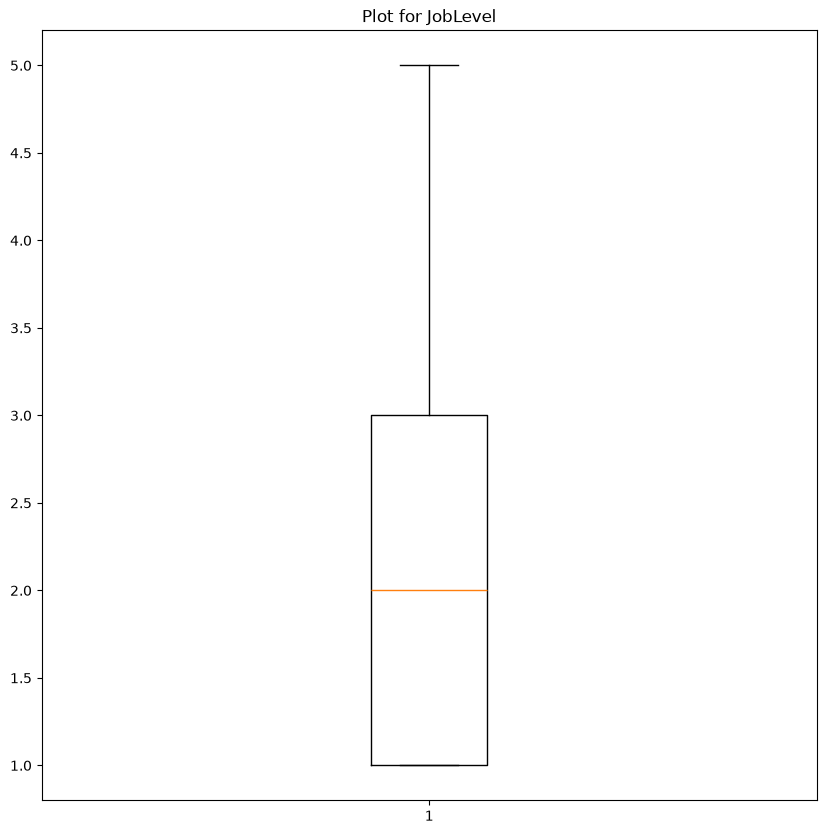

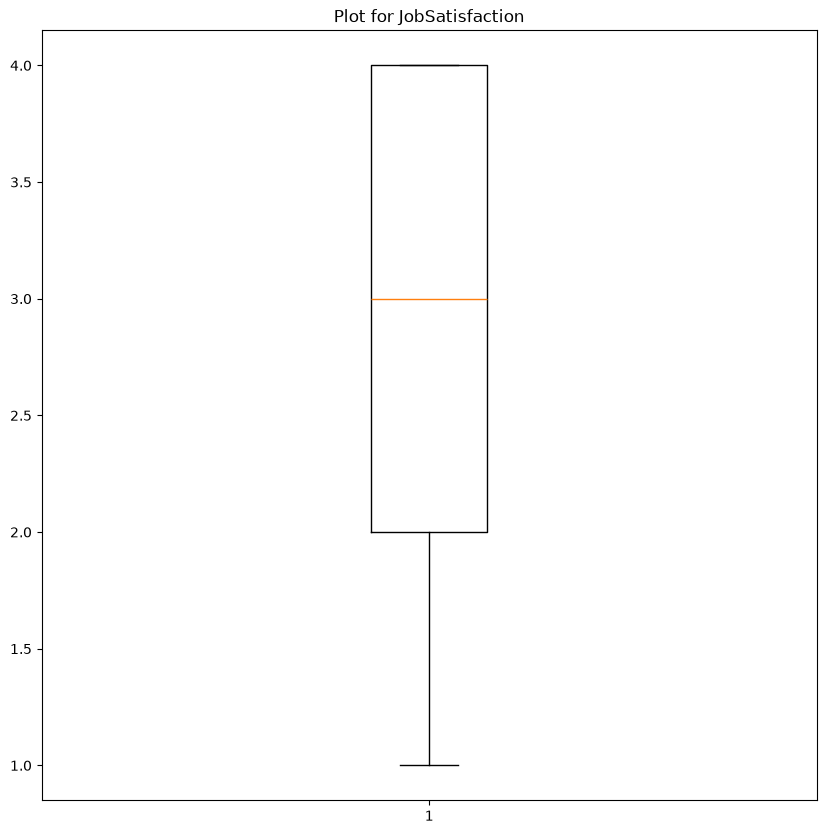

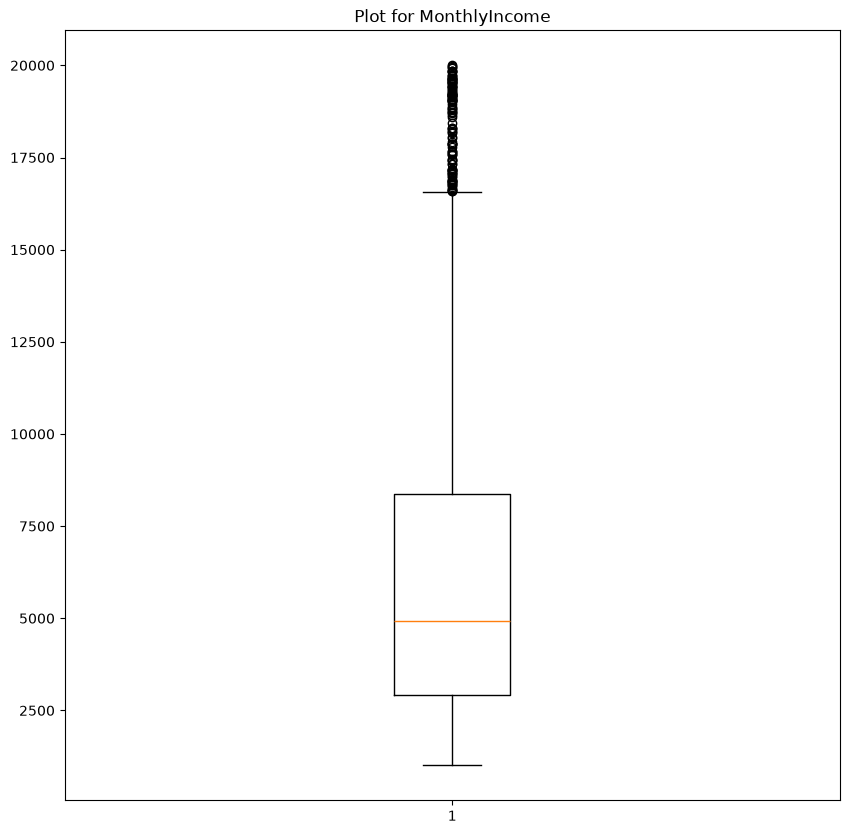

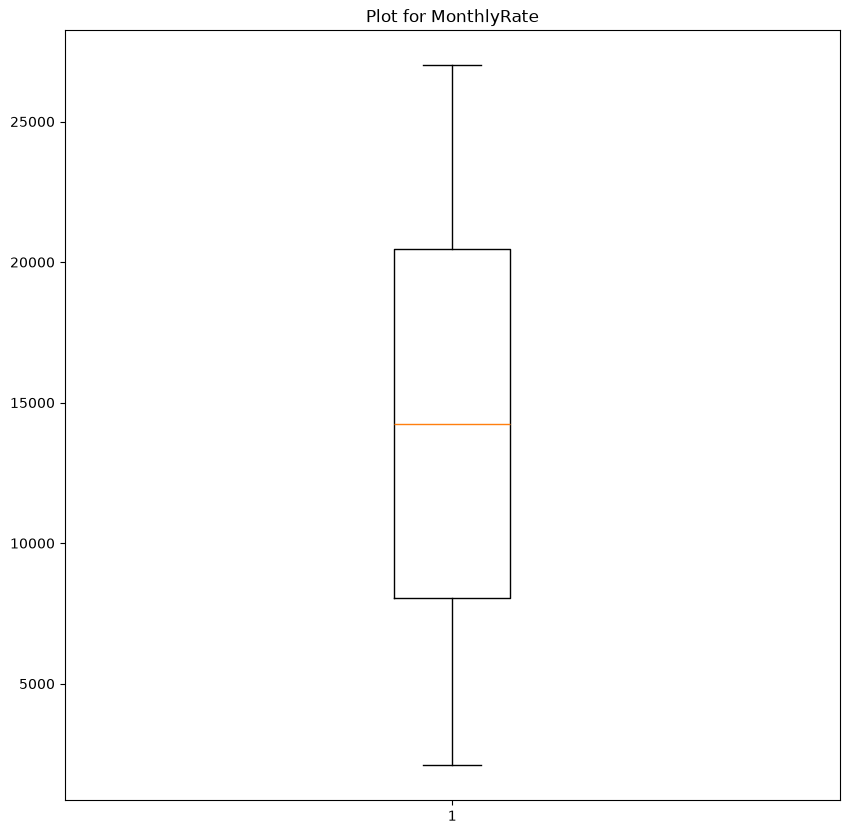

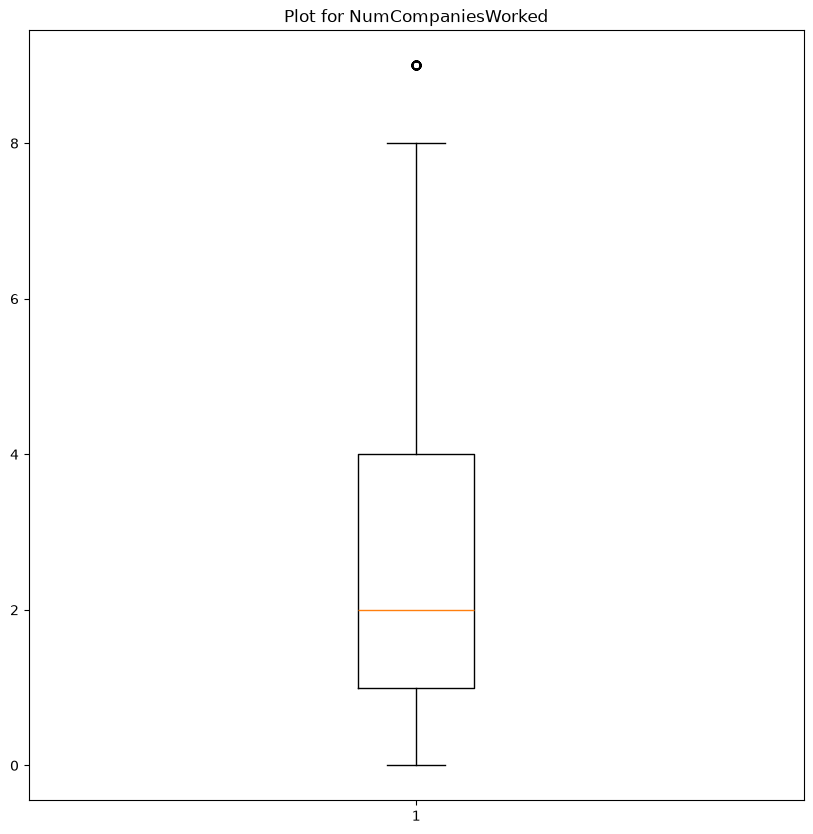

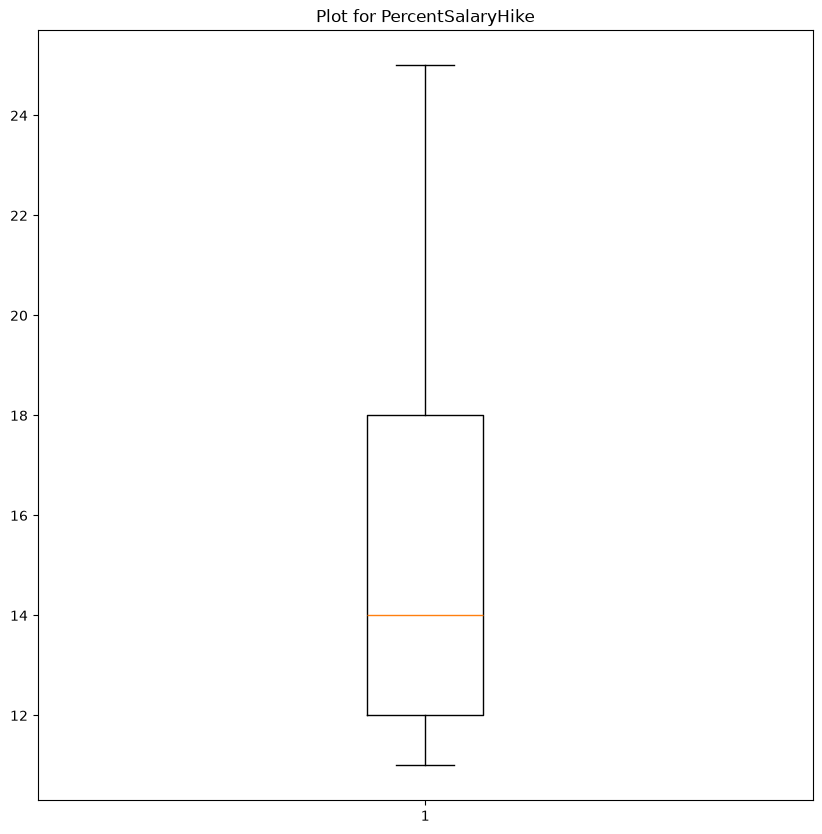

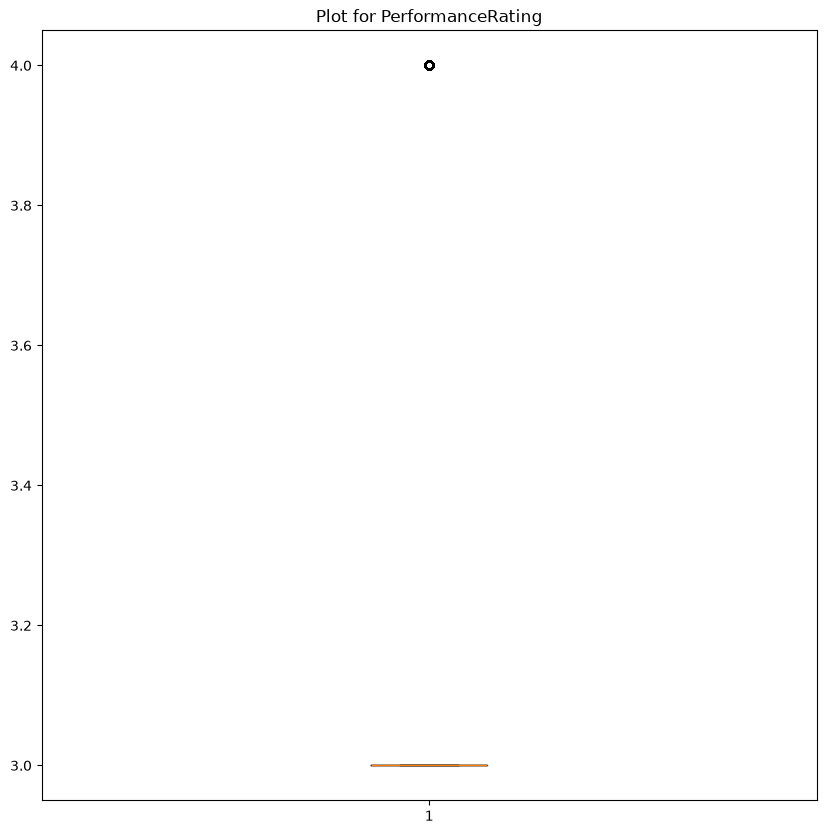

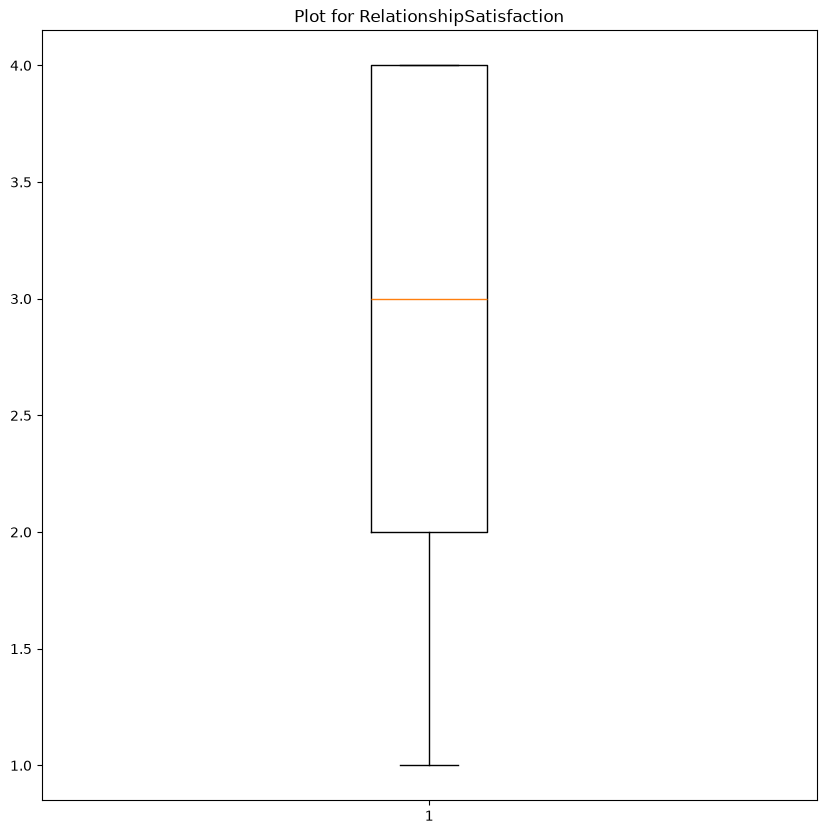

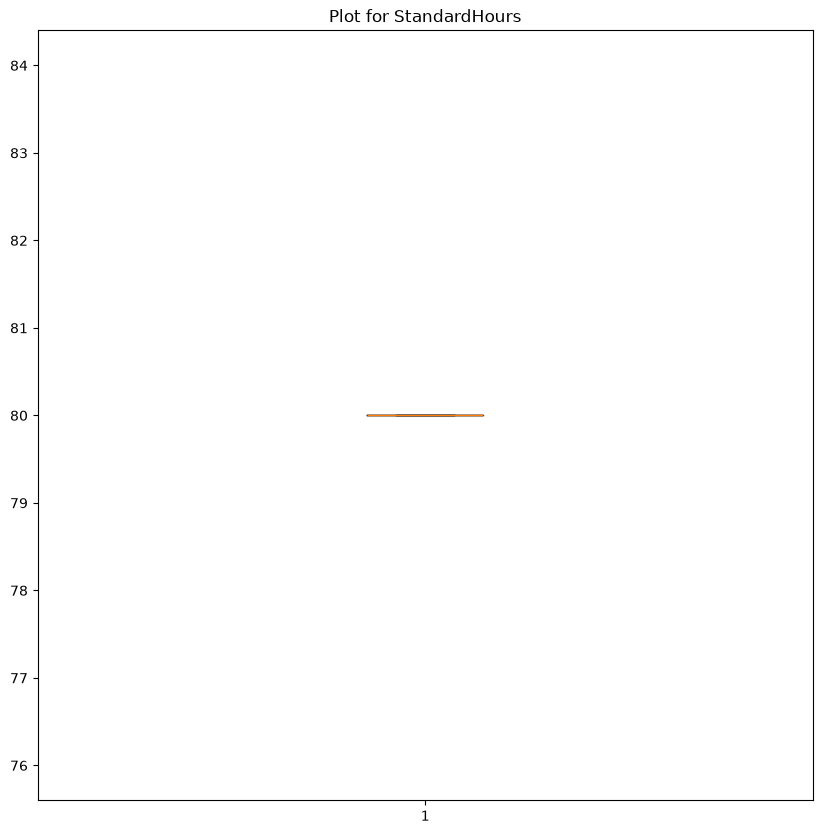

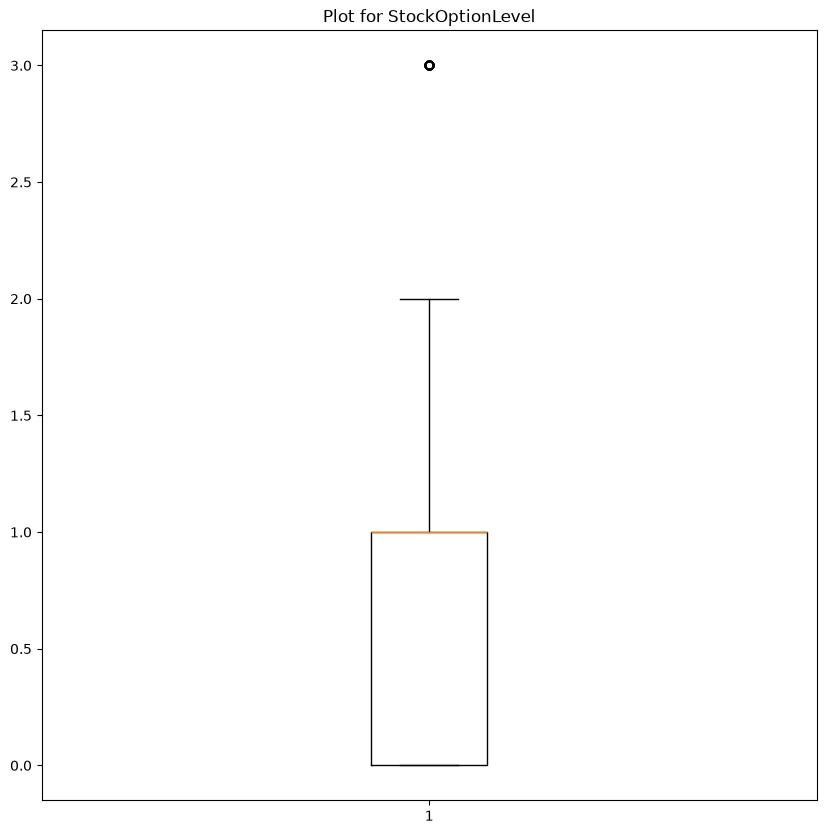

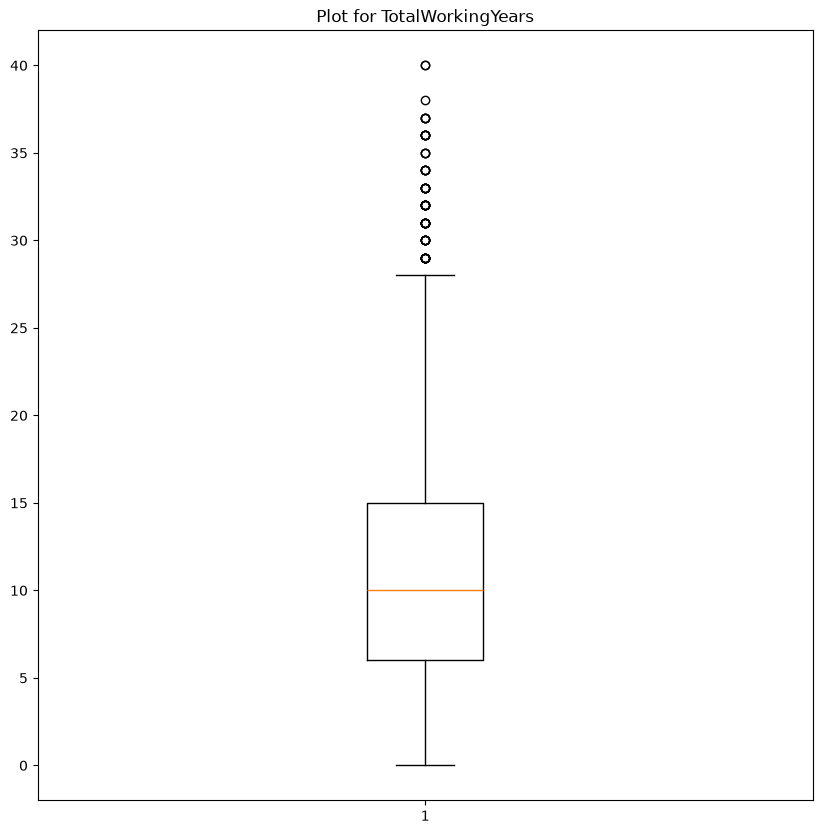

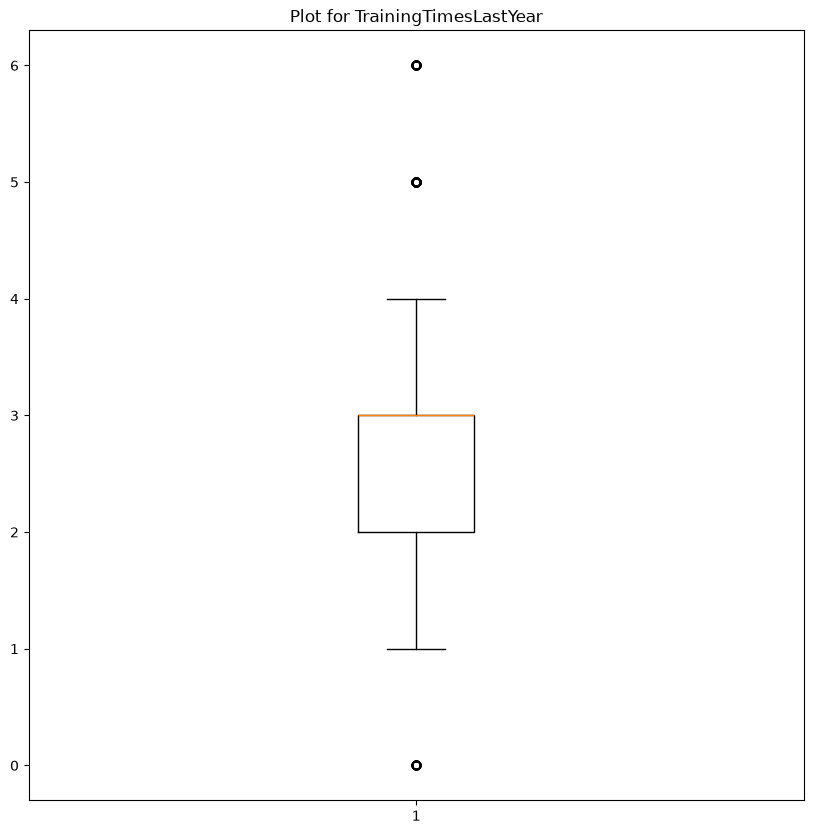

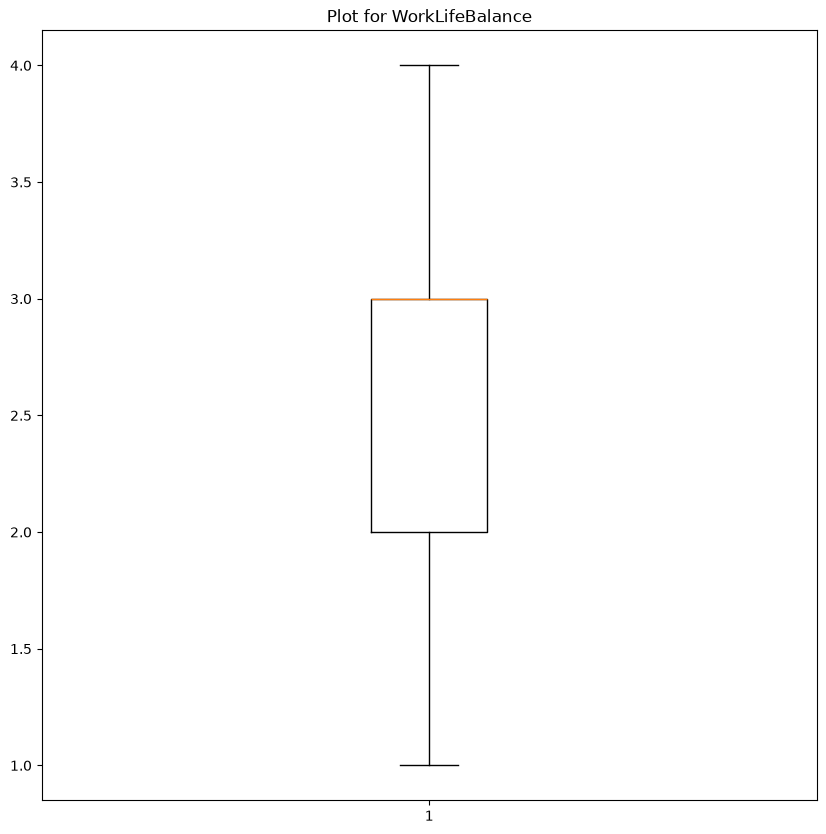

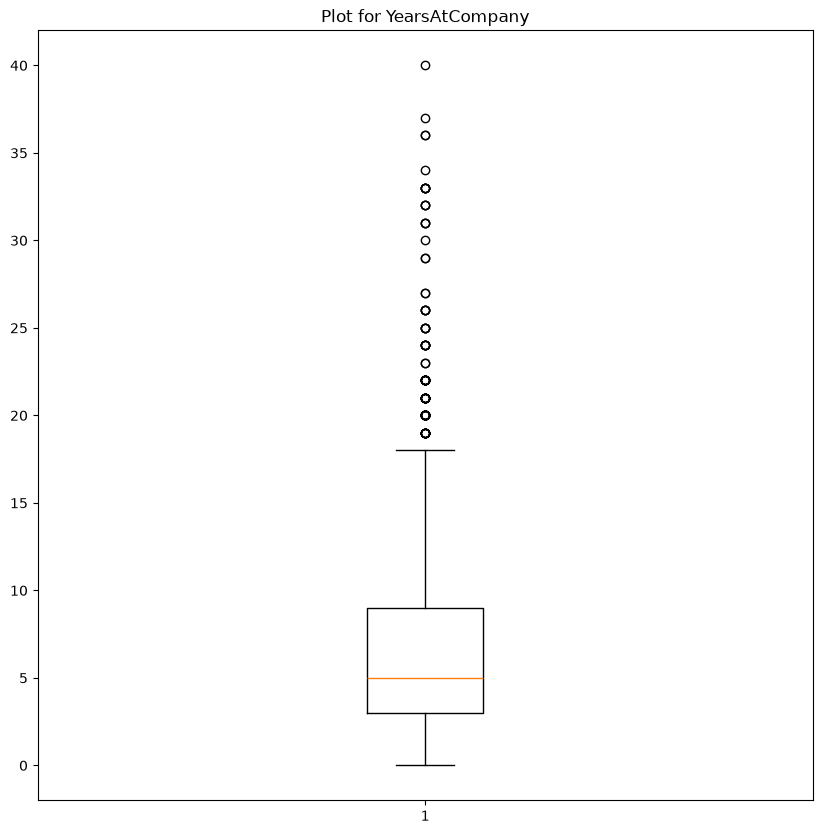

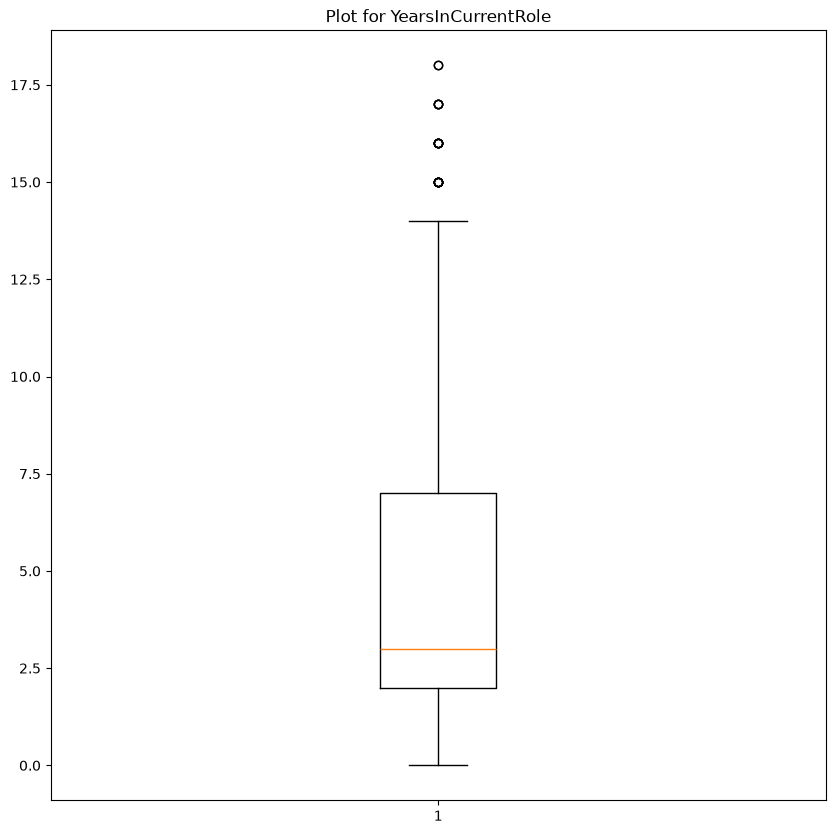

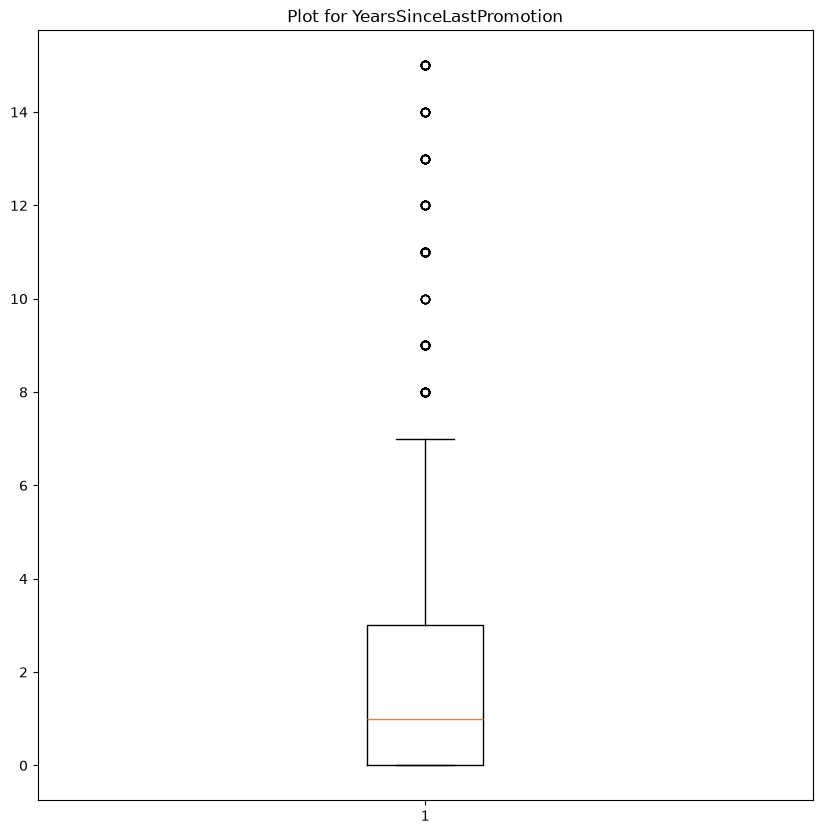

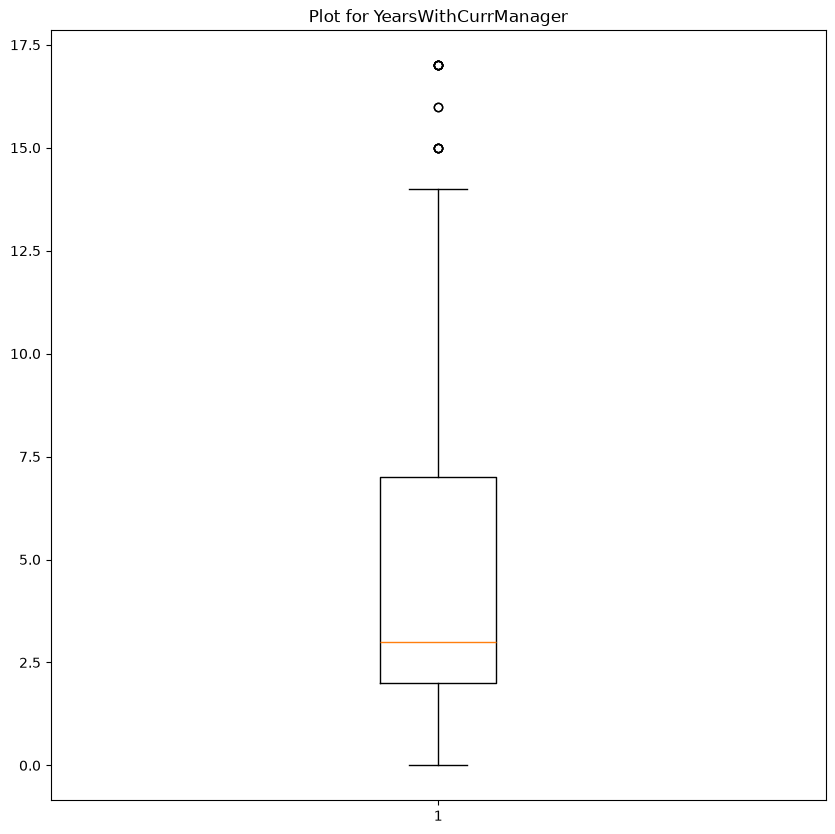

In [166]:
for col in NUMERICAL_COLUMNS:
    plt.figure(figsize=FIGURE_SIZE)
    plt.boxplot(x=df[col])
    plt.title(f"Plot for {col}")
    plt.show()

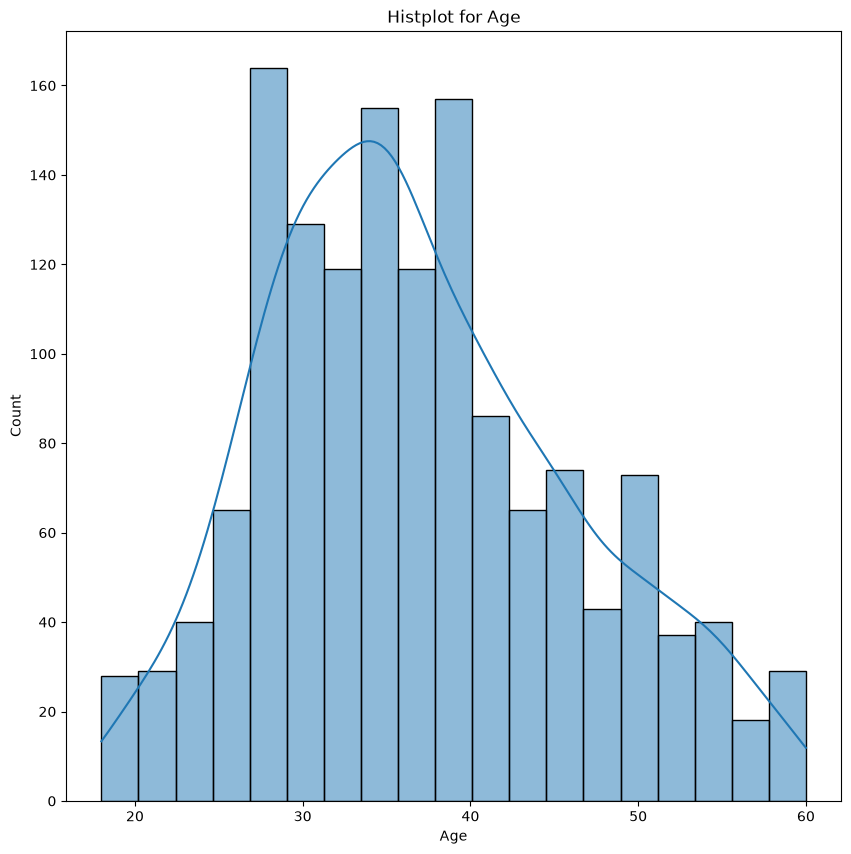

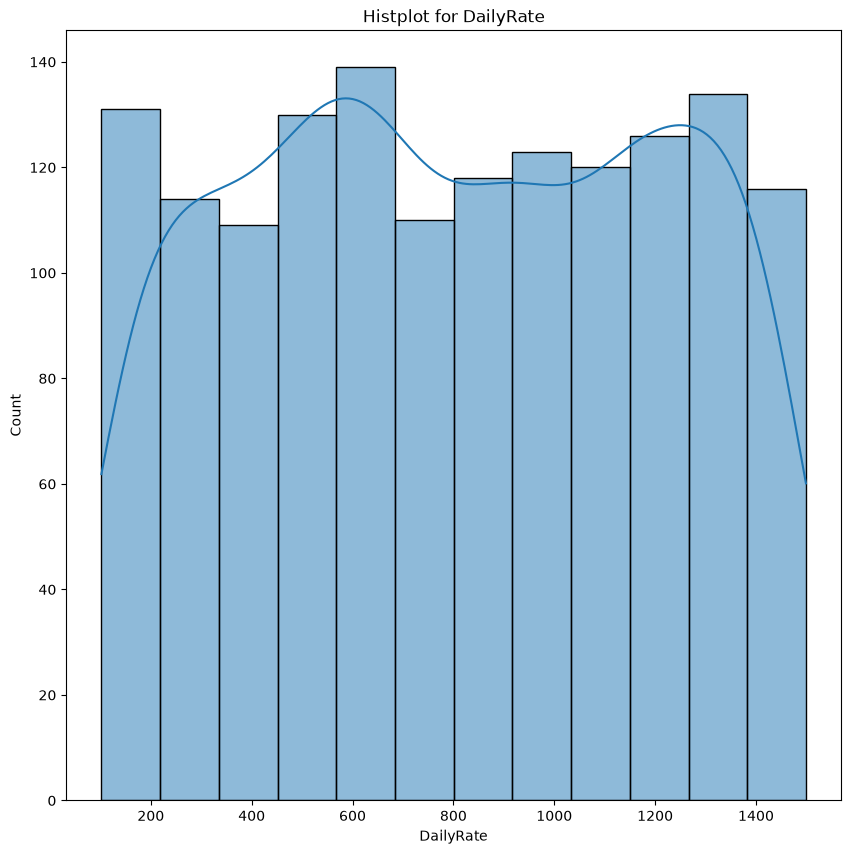

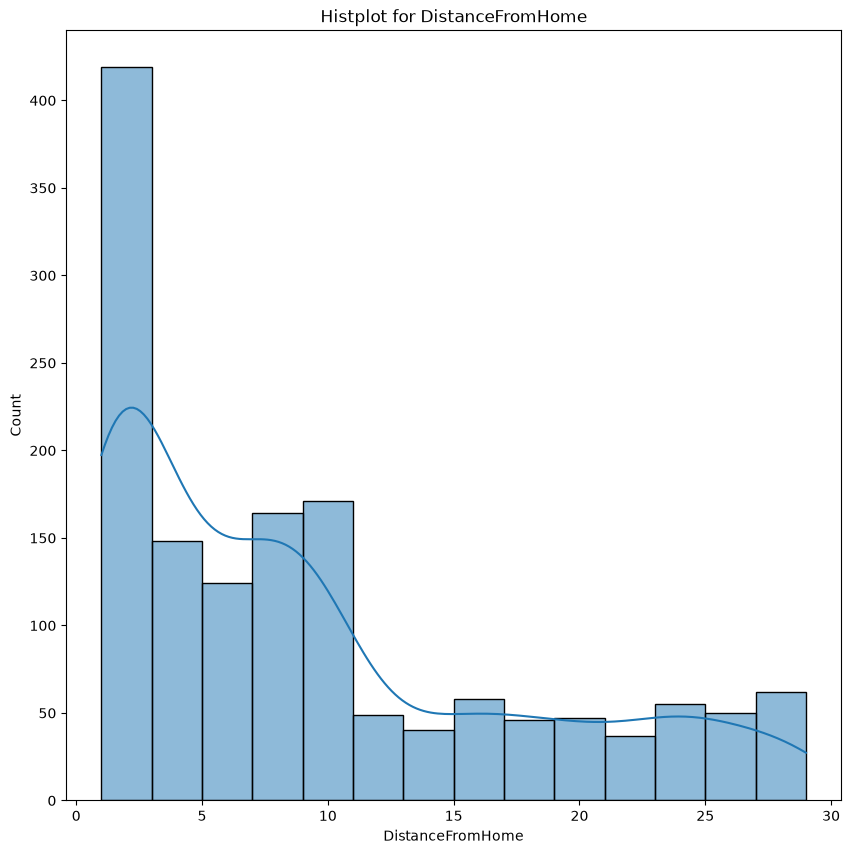

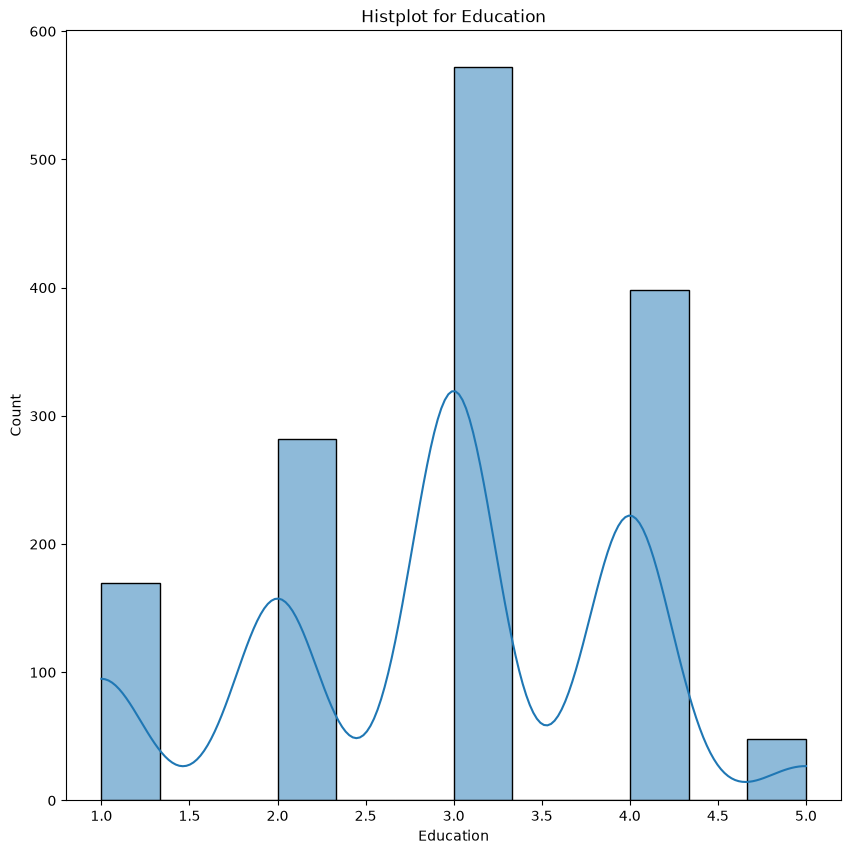

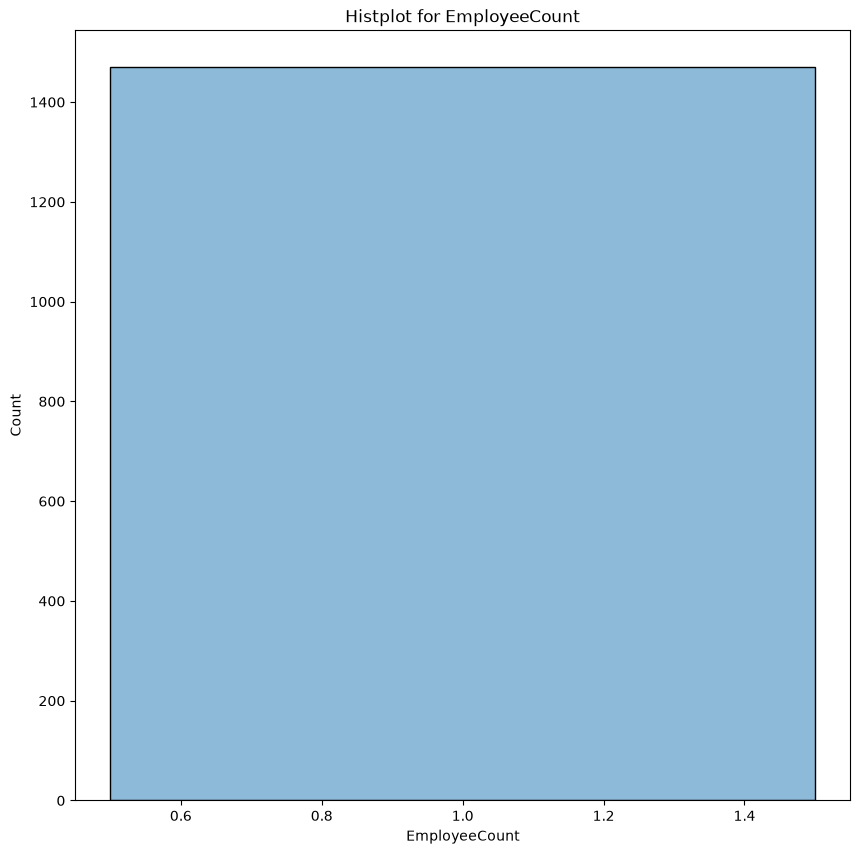

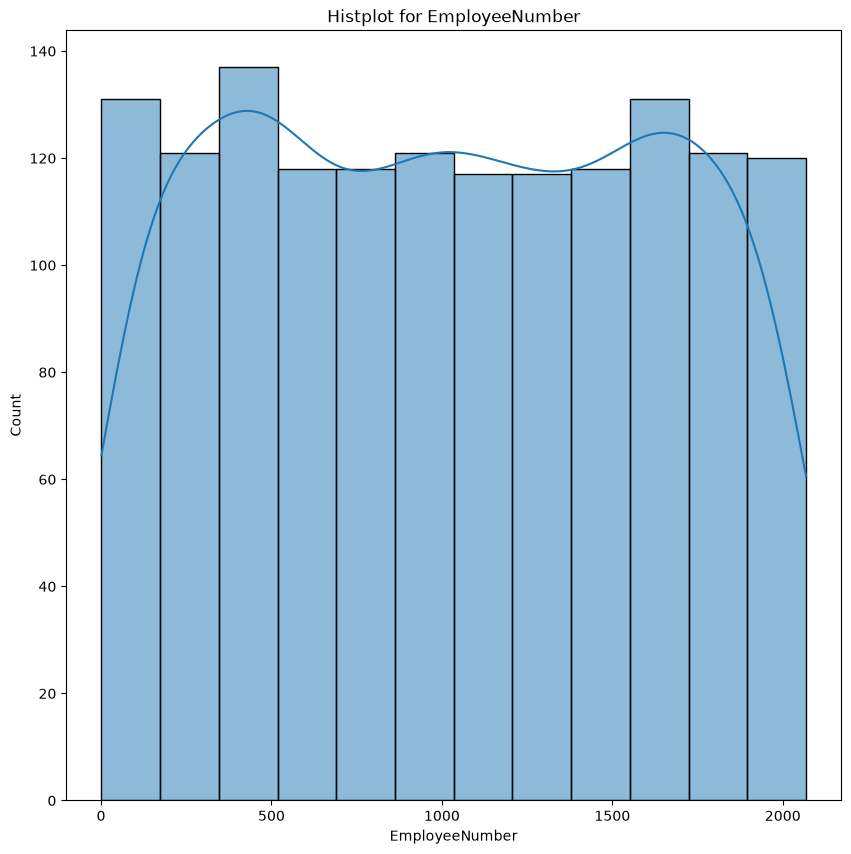

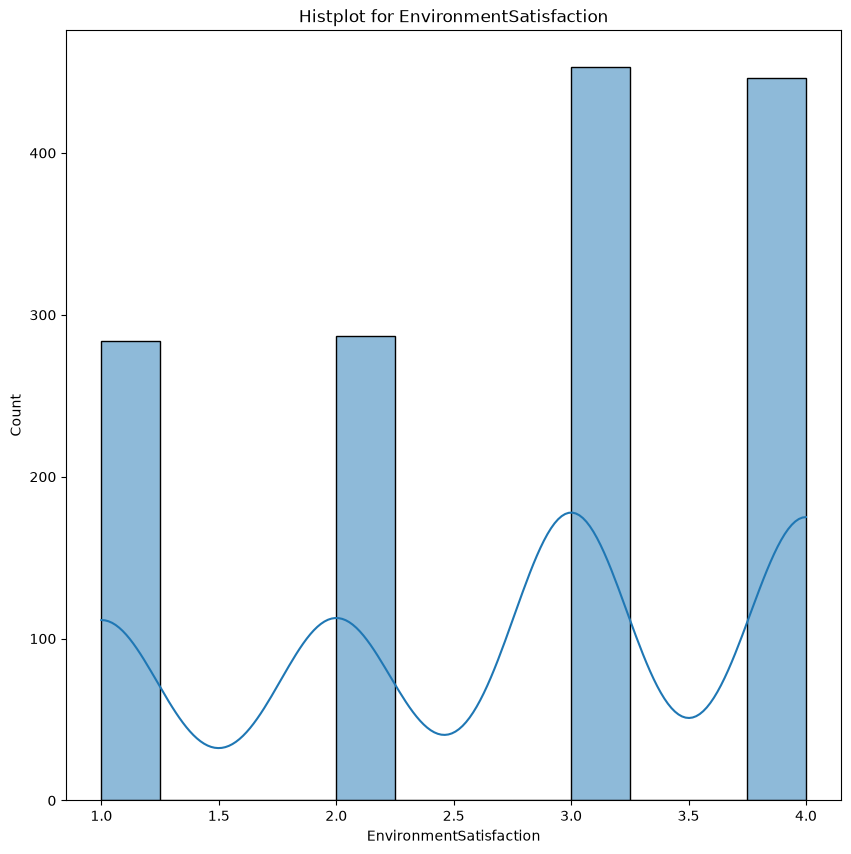

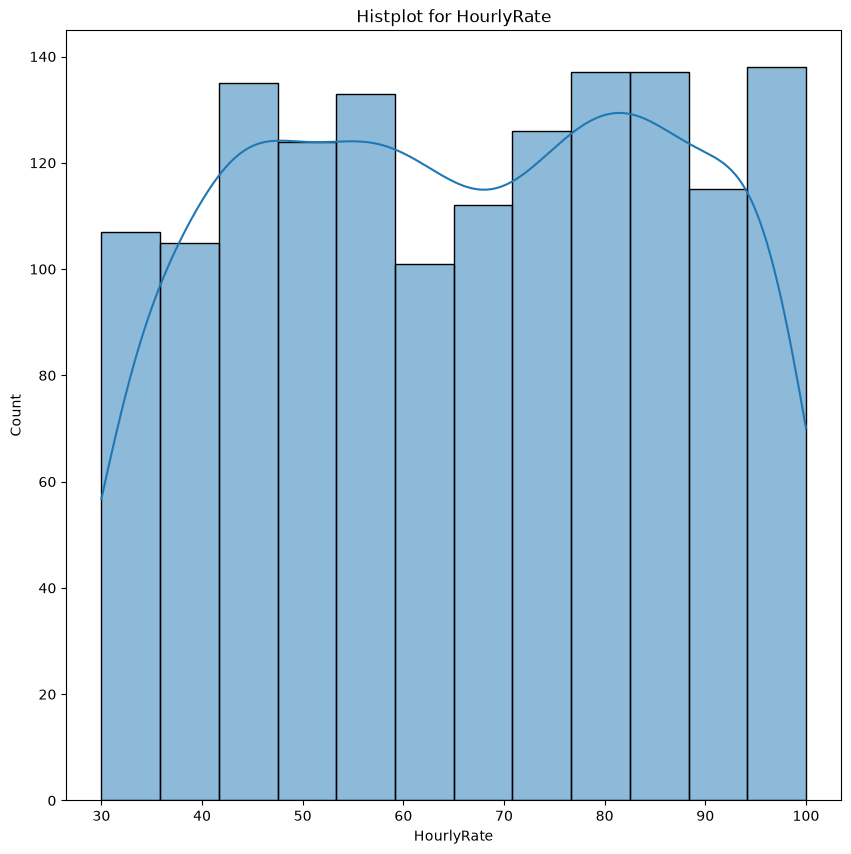

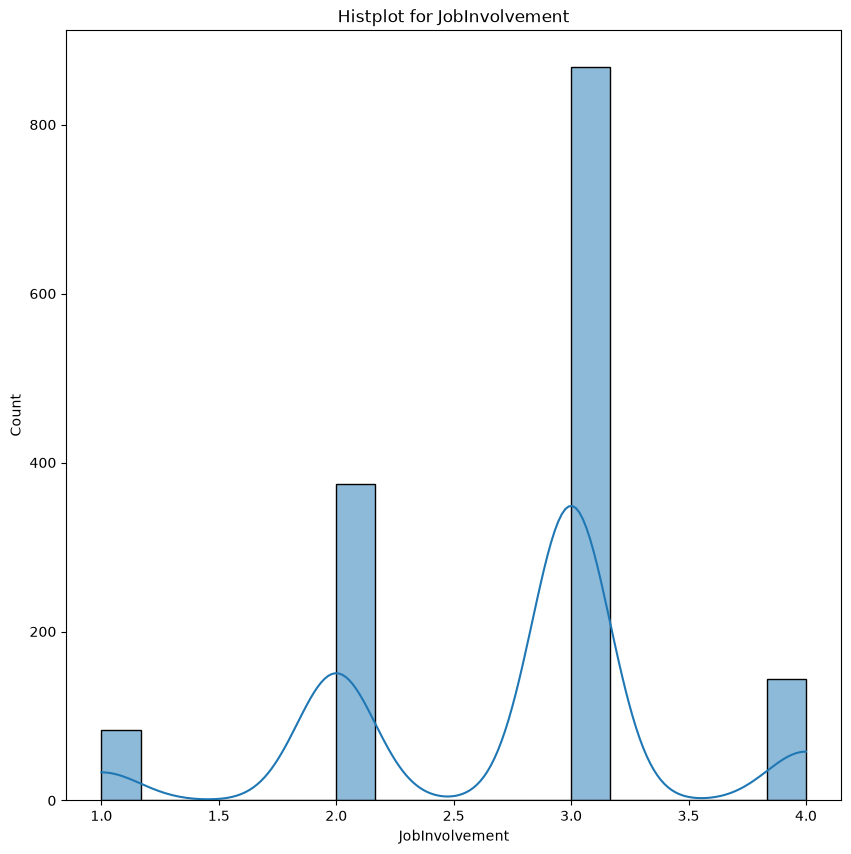

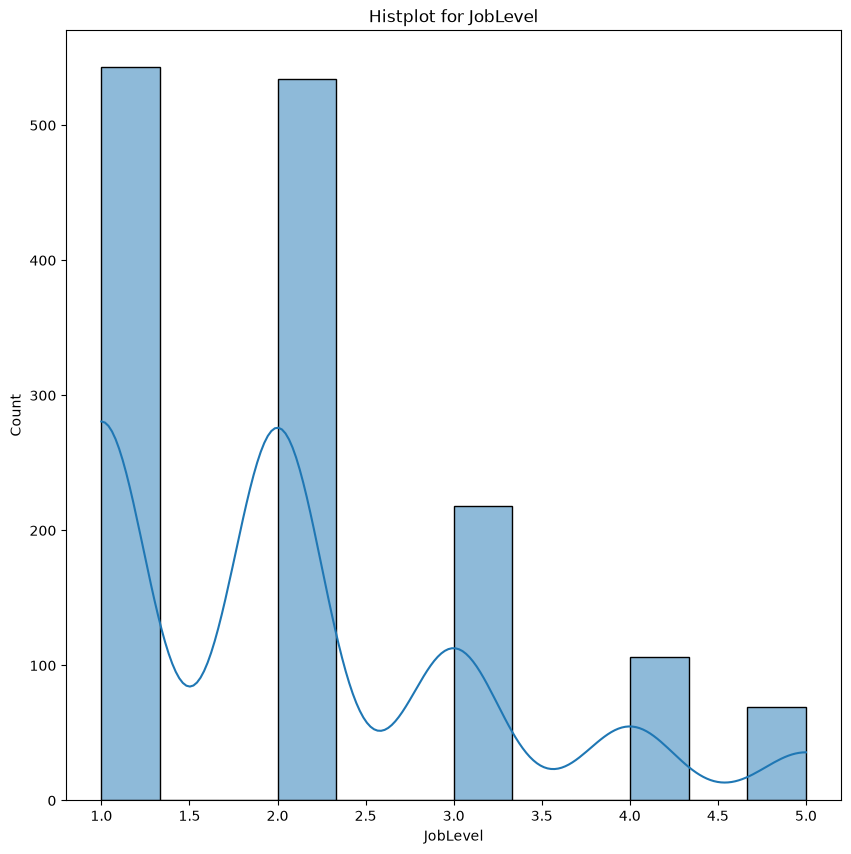

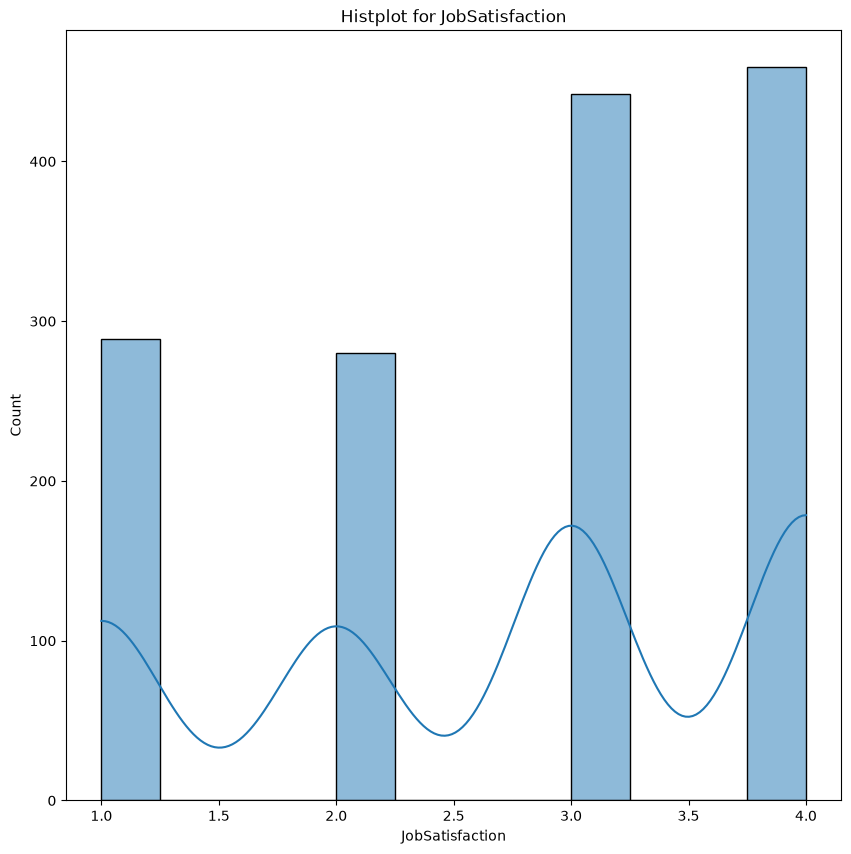

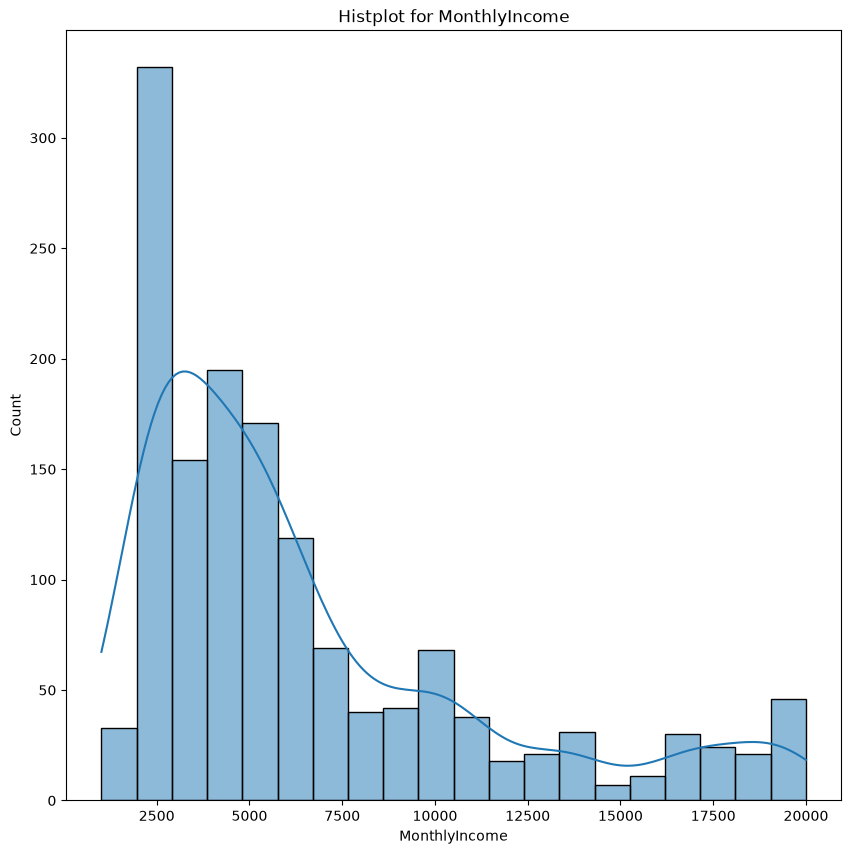

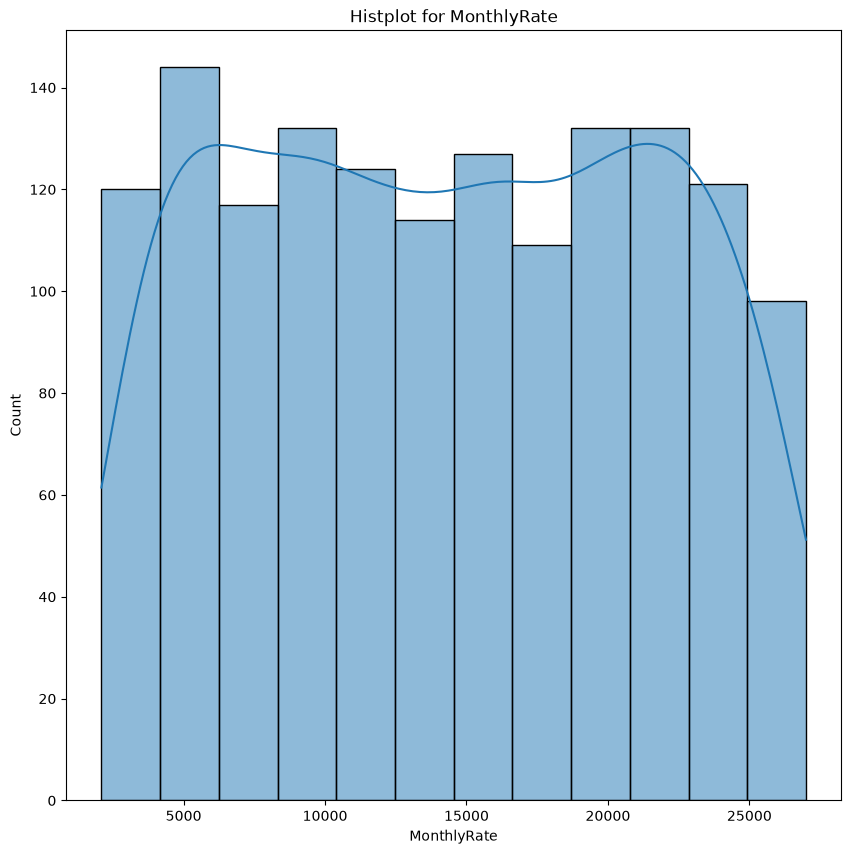

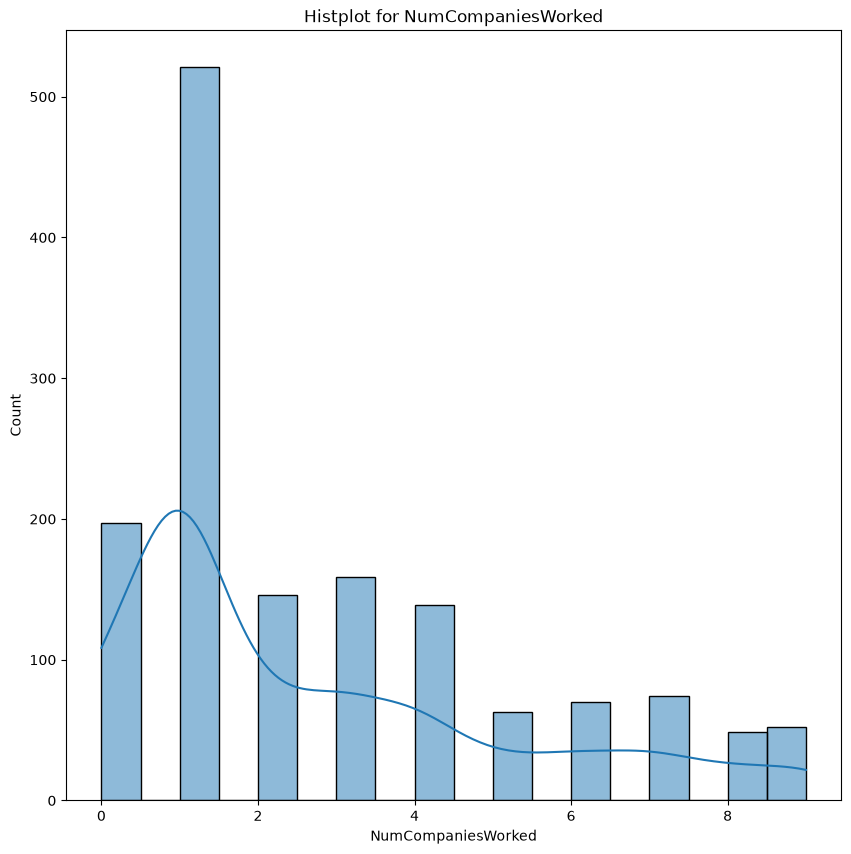

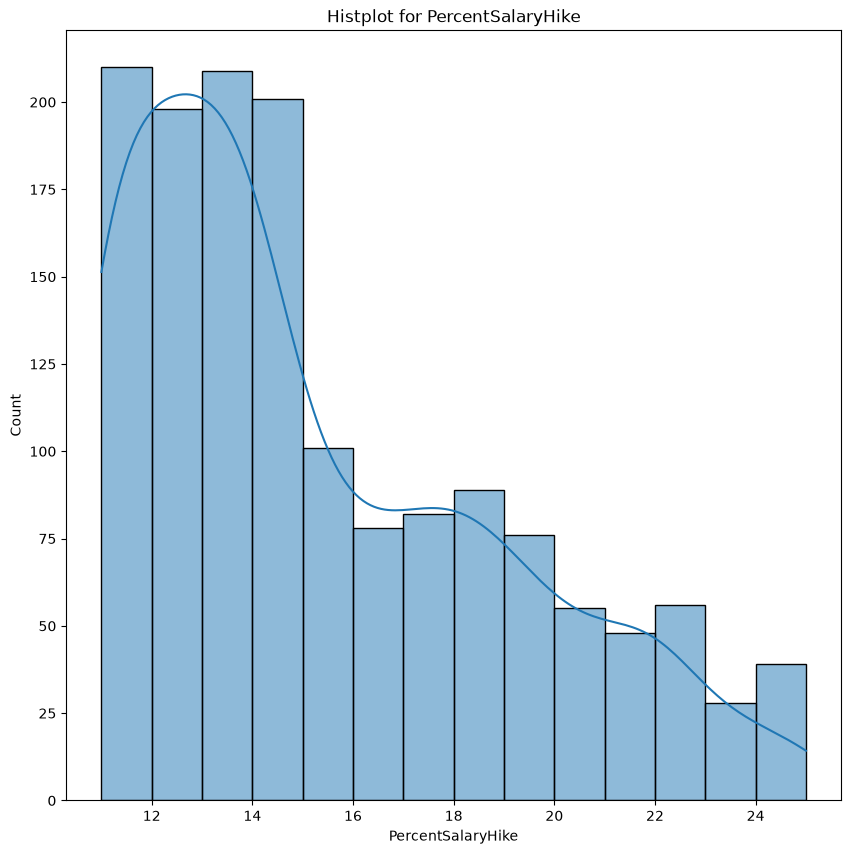

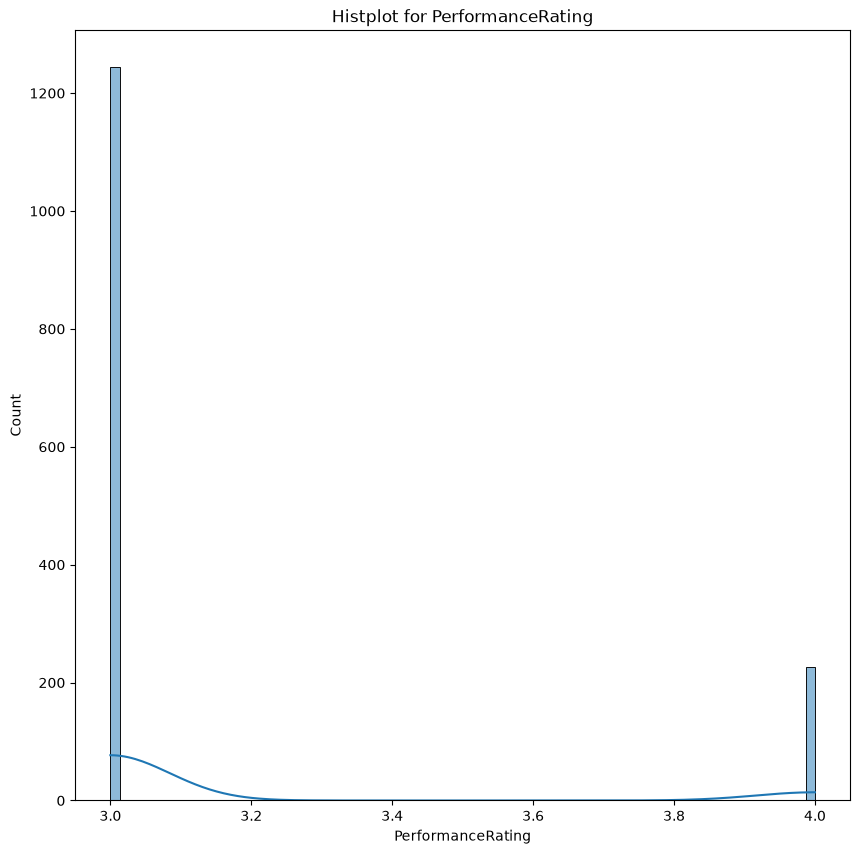

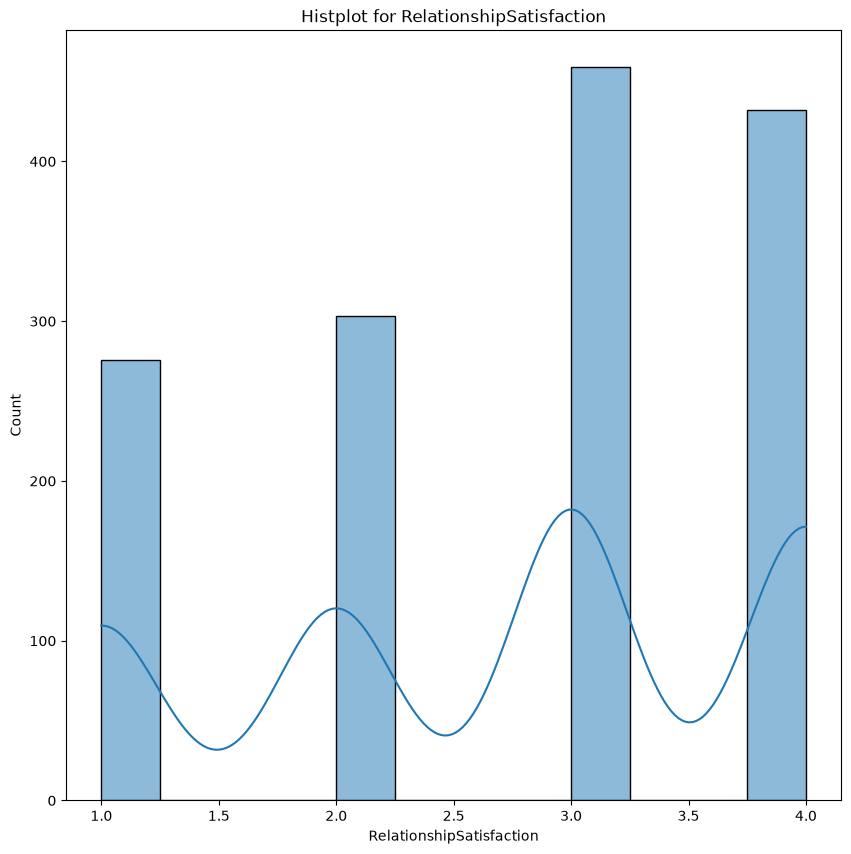

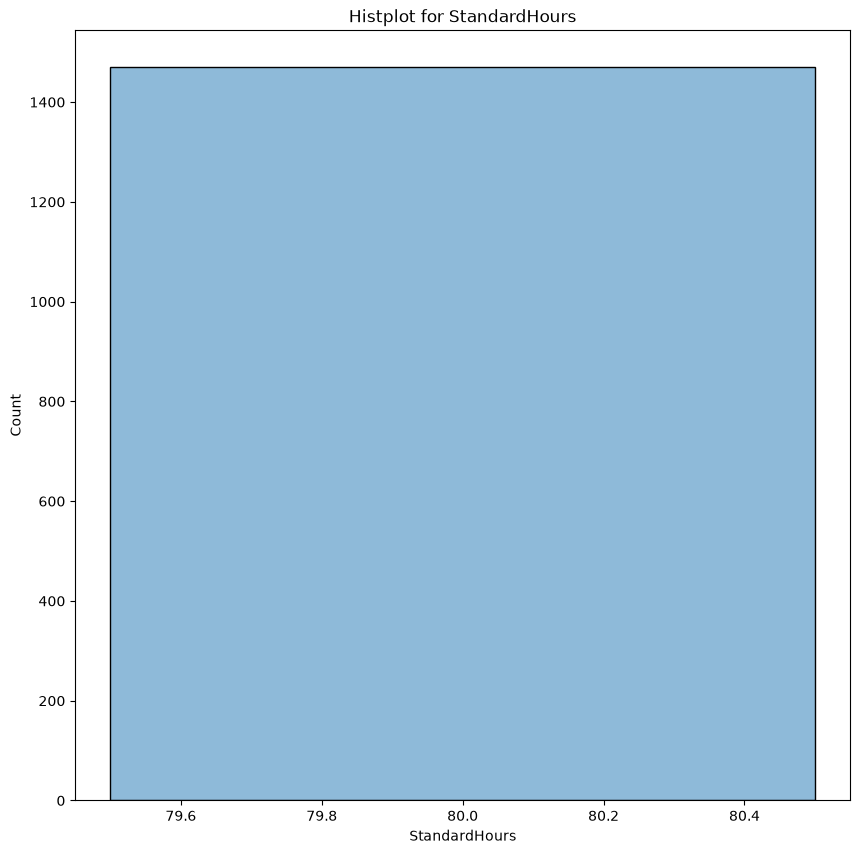

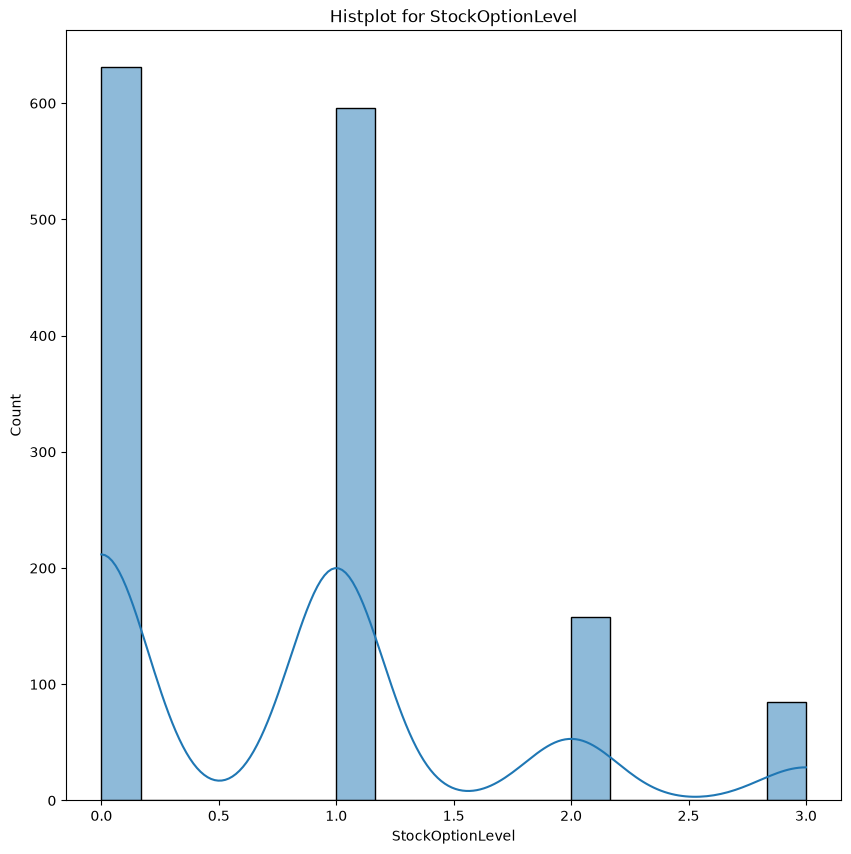

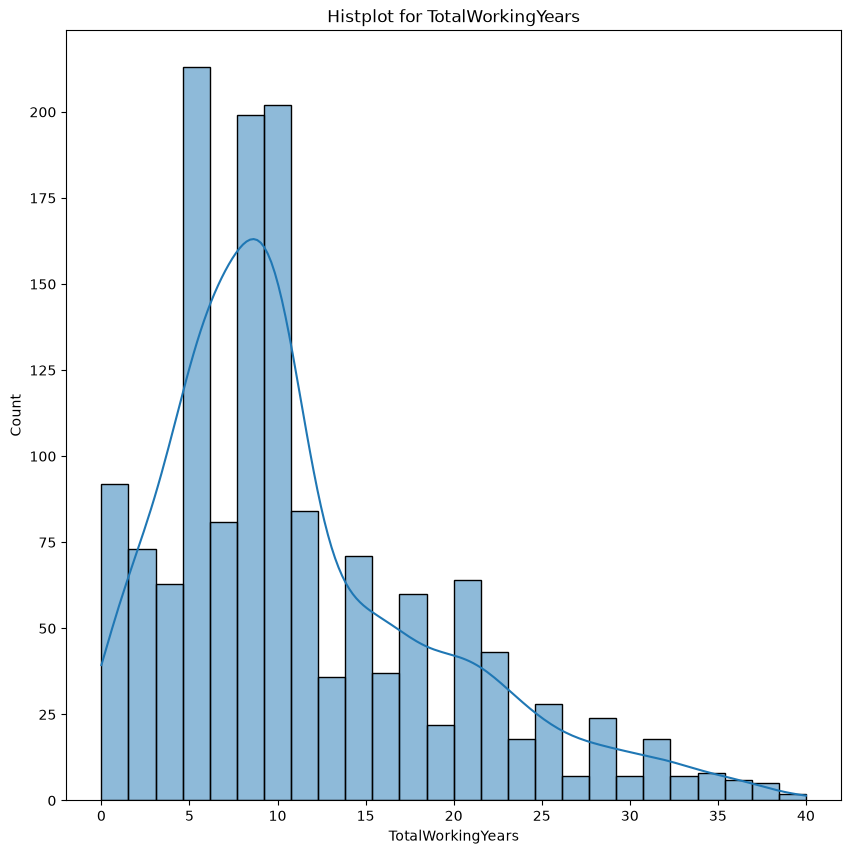

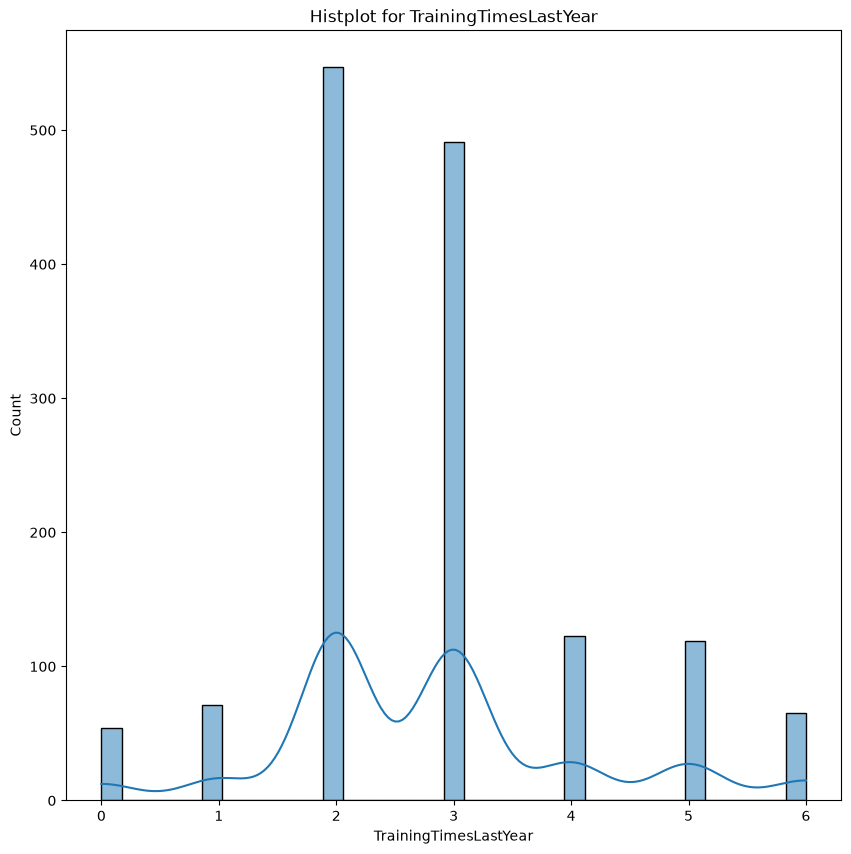

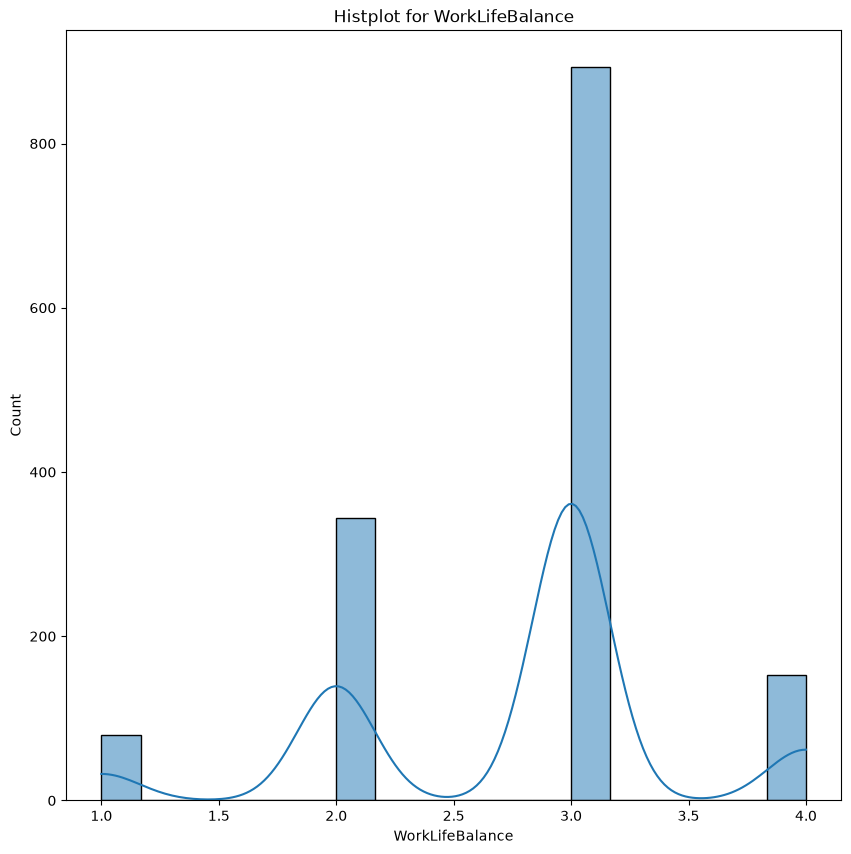

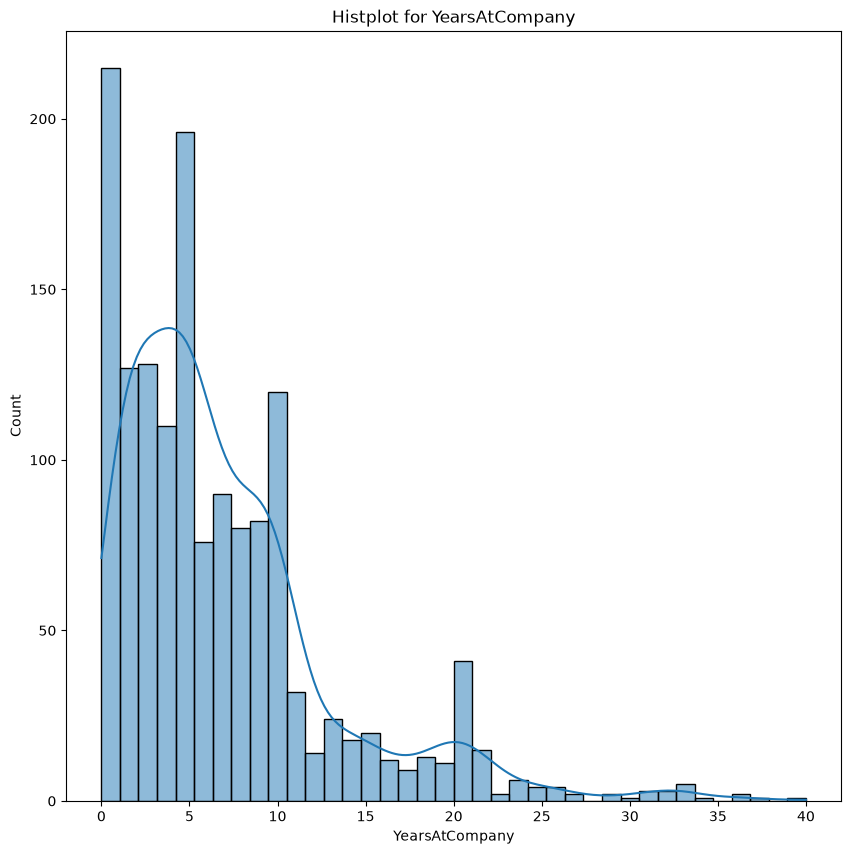

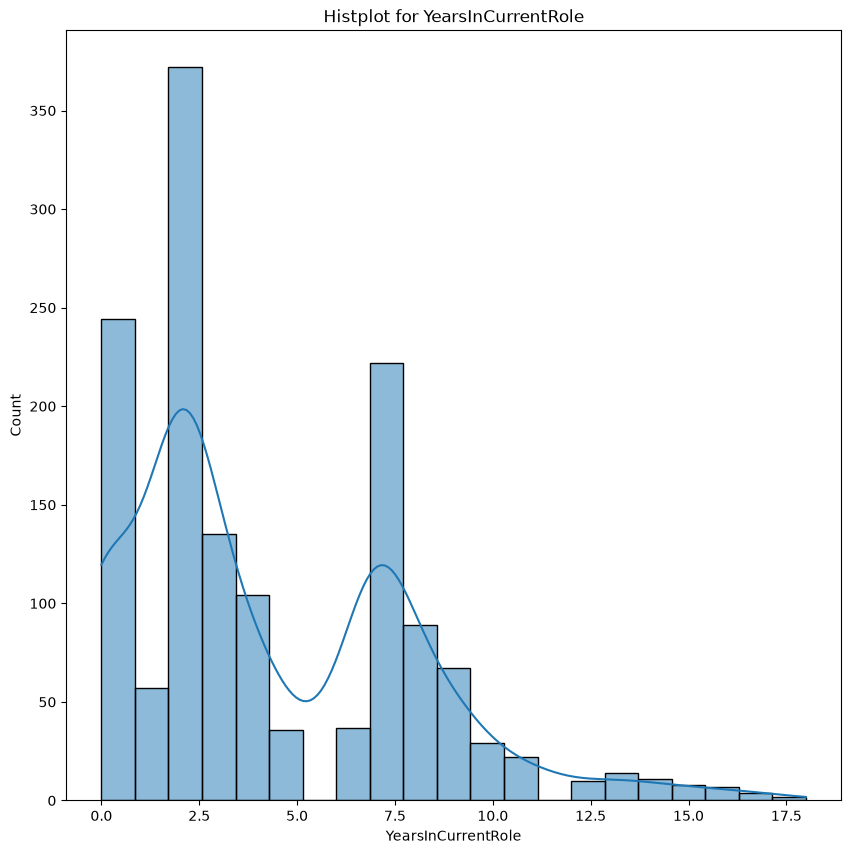

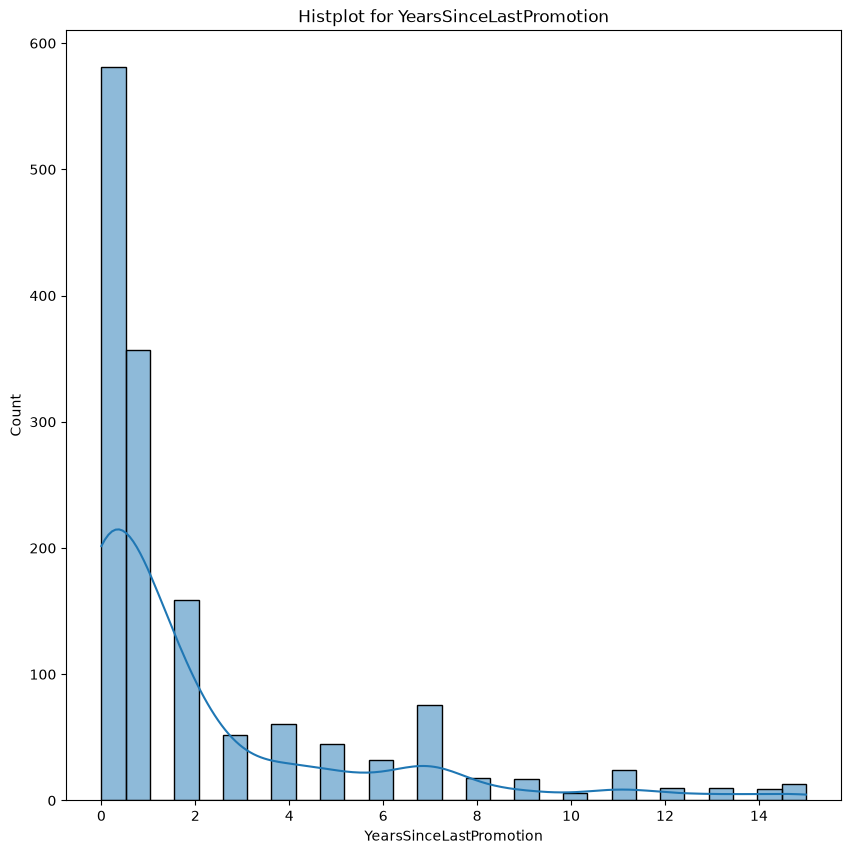

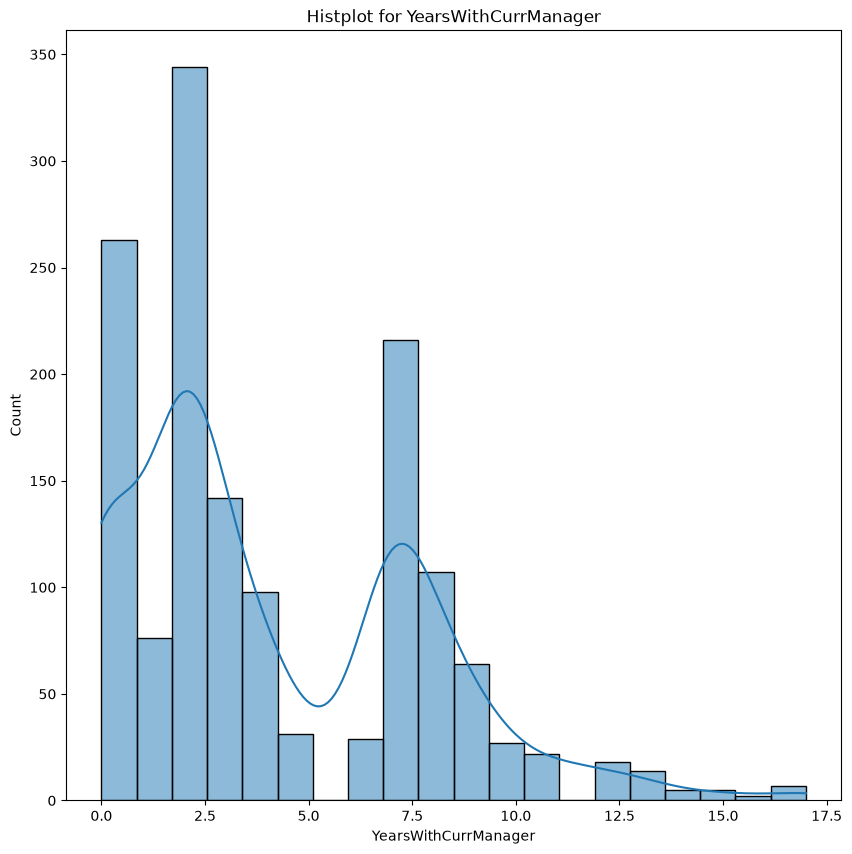

In [167]:
for col in NUMERICAL_COLUMNS:
    plt.figure(figsize=FIGURE_SIZE)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histplot for {col}")
    plt.show()

Based on the plots, for most of the columns is fairly distributed and for some the distribution is a bit skewed. Based on this observation and the overall visualization of outliers it can be concluded that the possible outliers are by value considered as outliers but are not logically outliers and can be kept. 

## 8. Correlation analysis

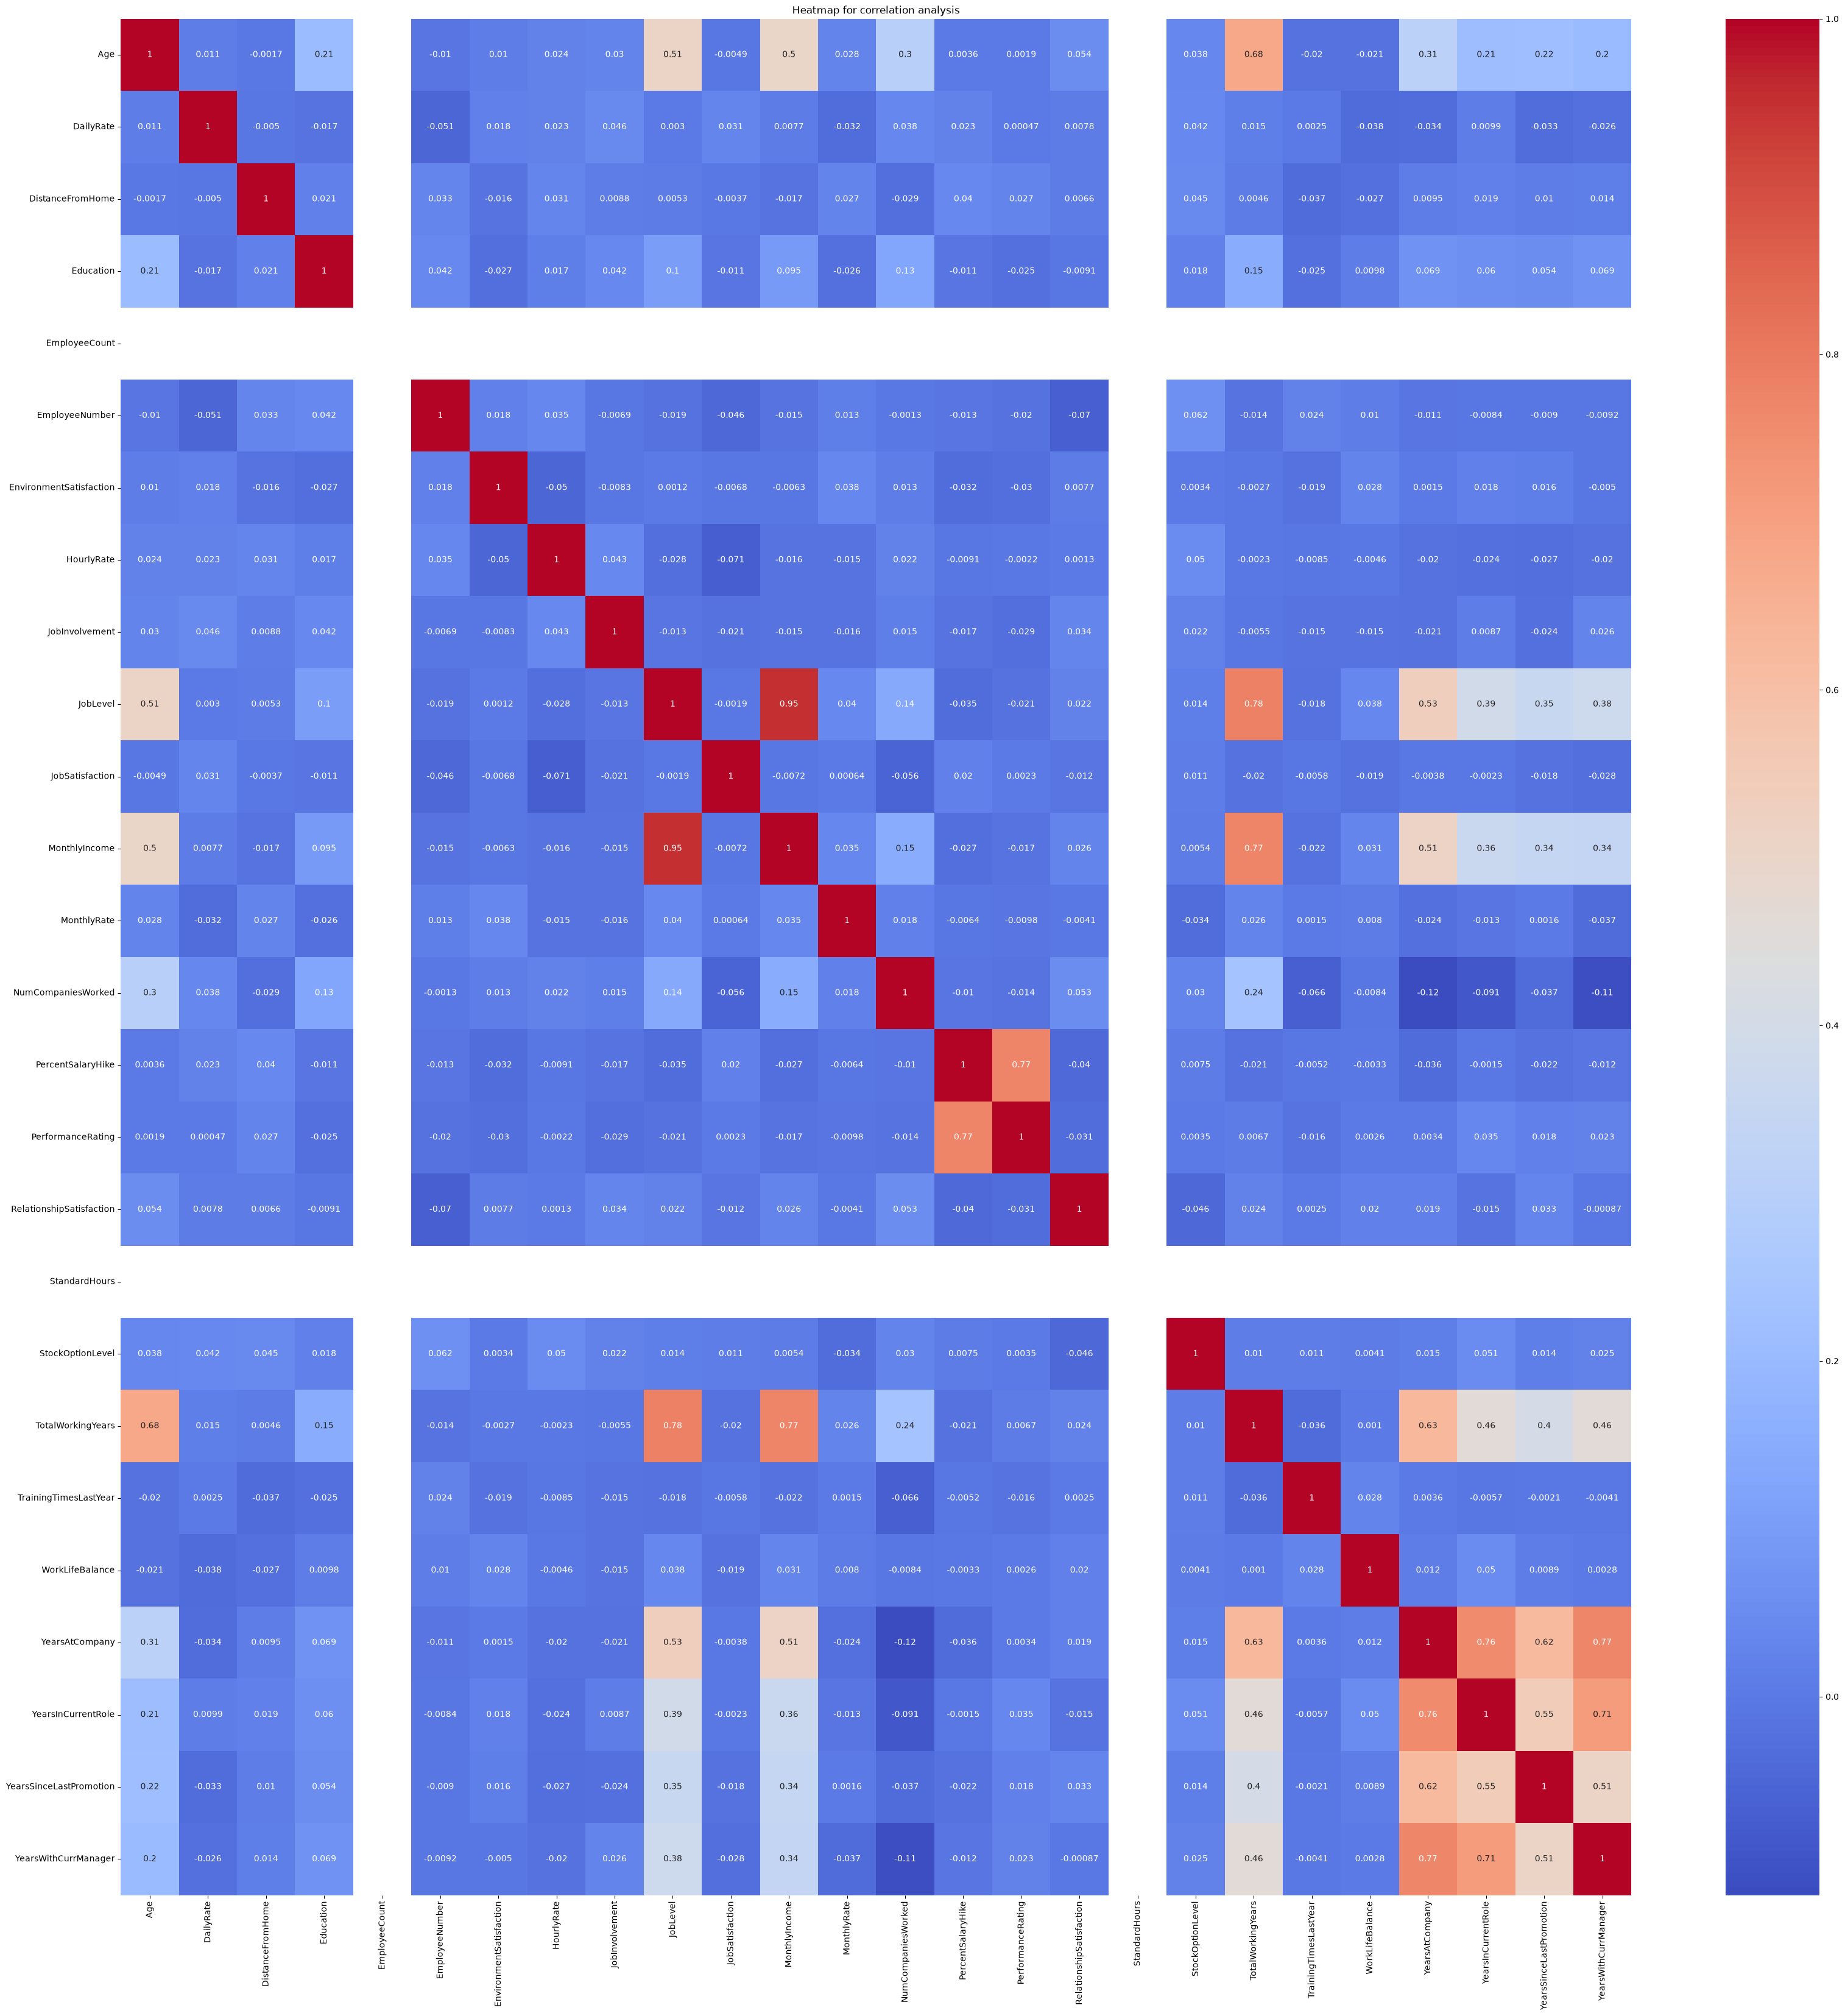

In [168]:
corr = NUMERICAL_COLUMNS.corr()

plt.figure(figsize=(40,40))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap for correlation analysis")
plt.show()

There are many significant positive and negative relations present in the dataset. Most of the relations also signify the logical relations and are completely expected

####  Preprocessing Decisions
✘ Can apply StandardScaler but not applied

Reason:
XGBoost is a tree-based algorithm and does not require feature scaling.

✓ Will apply encoding

Reason:
There are many categorical columns so we need to encode them so that model works as intended.

#### The columns that are binary and needs label encoding are as follows:
- Attrition
- Gender
- Over18
- OverTime

#### The columns that are multiple values and needs one hot encoding are as follows:
- Department
- EducationField
- JobRole
- MaritalStatus
- BusinessTravel

## 9. Label encoding the binary categorical columns

In [169]:
label_encoders = {}

In [170]:
for col in LABEL_ENCODE_COLUMNS:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    label_encoders[col] = encoder

In [171]:
df[LABEL_ENCODE_COLUMNS].head(3)

,Attrition,Gender,Over18,OverTime
0,1,0,0,1
1,0,1,0,0
2,1,1,0,1


In [172]:
df[LABEL_ENCODE_COLUMNS].sample(3)

,Attrition,Gender,Over18,OverTime
660,1,1,0,1
373,0,1,0,0
546,0,1,0,0


## 10. One Hot encoding the respective columns

In [173]:
one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output= False
)

In [174]:
encoded_array = one_hot_encoder.fit_transform(df[ONEHOT_ENCODE_COLUMNS])

In [175]:
encoded_columns = one_hot_encoder.get_feature_names_out(ONEHOT_ENCODE_COLUMNS)

In [176]:
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=df.index
)

In [177]:
df = df.drop(columns=ONEHOT_ENCODE_COLUMNS)

In [178]:
df = pd.concat([df, encoded_df], axis=1)

In [179]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,41,1,1102,1,2,1,1,2,0,94,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,49,0,279,8,1,1,2,3,1,61,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,1373,2,2,1,4,4,1,92,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,33,0,1392,3,4,1,5,4,0,56,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,27,0,591,2,1,1,7,1,1,40,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## 11. Preparing the data for model training

In [180]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

In [181]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1176, 53)
(294, 53)
(1176,)
(294,)


## 12. Training the model from the data prepared

In [206]:
xgb_model = XGBClassifier(**XGB_PARAMS)

In [207]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 13. Evaluation of the model metrics

In [208]:
y_pred = xgb_model.predict(X_test)

y_pred_probablity = xgb_model.predict_proba(X_test)[:, 1]

In [209]:
evaluate_model(y_pred, y_pred_probablity, y_test)

Accuracy score:  0.8809523809523809

 ROC AUC score:  0.8182001005530417

 Confusion matrix: 
 [[247   8]
 [ 27  12]]

 Classification report: 
               precision    recall  f1-score   support

           0       0.90      0.97      0.93       255
           1       0.60      0.31      0.41        39

    accuracy                           0.88       294
   macro avg       0.75      0.64      0.67       294
weighted avg       0.86      0.88      0.86       294



## 14. Checking the model output prediction

In [212]:
df_predict_attrition = pd.DataFrame([{
    'Age': 24, 'DailyRate': 400, 'DistanceFromHome': 25, 'Education': 1, 
    'EmployeeCount': 1, 'EmployeeNumber': 9991, 'EnvironmentSatisfaction': 1, 
    'Gender': 1, 'HourlyRate': 45, 'JobInvolvement': 1, 'JobLevel': 1, 
    'JobSatisfaction': 1, 'MonthlyIncome': 2200, 'MonthlyRate': 10000, 
    'NumCompaniesWorked': 6, 'Over18': 1, 'OverTime': 1, 
    'PercentSalaryHike': 11, 'PerformanceRating': 3, 'RelationshipSatisfaction': 1, 
    'StandardHours': 80, 'StockOptionLevel': 0, 'TotalWorkingYears': 2, 
    'TrainingTimesLastYear': 0, 'WorkLifeBalance': 1, 'YearsAtCompany': 1, 
    'YearsInCurrentRole': 0, 'YearsSinceLastPromotion': 0, 'YearsWithCurrManager': 0,
    
    # Categoricals (Sales Rep, Single, Travels Frequently)
    'Department_Human Resources': 0, 'Department_Research & Development': 0, 'Department_Sales': 1,
    'EducationField_Human Resources': 0, 'EducationField_Life Sciences': 0, 'EducationField_Marketing': 1,
    'EducationField_Medical': 0, 'EducationField_Other': 0, 'EducationField_Technical Degree': 0,
    'JobRole_Healthcare Representative': 0, 'JobRole_Human Resources': 0, 'JobRole_Laboratory Technician': 0,
    'JobRole_Manager': 0, 'JobRole_Manufacturing Director': 0, 'JobRole_Research Director': 0,
    'JobRole_Research Scientist': 0, 'JobRole_Sales Executive': 0, 'JobRole_Sales Representative': 1,
    'MaritalStatus_Divorced': 0, 'MaritalStatus_Married': 0, 'MaritalStatus_Single': 1,
    'BusinessTravel_Non-Travel': 0, 'BusinessTravel_Travel_Frequently': 1, 'BusinessTravel_Travel_Rarely': 0
}])

display_prediction_examples(xgb_model, df_predict_attrition)

Predicted Attrition:  [1]


In [214]:
df_out_of_scope = pd.DataFrame([{
    'Age': -15, 'DailyRate': np.nan, 'DistanceFromHome': 5000, 'Education': 9, 
    'EmployeeCount': 1, 'EmployeeNumber': np.nan, 'EnvironmentSatisfaction': 8, 
    'Gender': 3, 'HourlyRate': -50, 'JobInvolvement': np.nan, 'JobLevel': 10, 
    'JobSatisfaction': 0, 'MonthlyIncome': np.nan, 'MonthlyRate': 0, 
    'NumCompaniesWorked': -2, 'Over18': np.nan, 'OverTime': 5, 
    'PercentSalaryHike': np.nan, 'PerformanceRating': 10, 'RelationshipSatisfaction': np.nan, 
    'StandardHours': 80, 'StockOptionLevel': np.nan, 'TotalWorkingYears': 200, 
    'TrainingTimesLastYear': np.nan, 'WorkLifeBalance': 9, 'YearsAtCompany': 50, 
    'YearsInCurrentRole': 60, 'YearsSinceLastPromotion': np.nan, 'YearsWithCurrManager': np.nan,
    
    # Broken Categoricals: Employee is simultaneously Single, Married, AND Divorced.
    # Also missing valid Department/JobRole indicators (all set to 0).
    'Department_Human Resources': 0, 'Department_Research & Development': 0, 'Department_Sales': 0,
    'EducationField_Human Resources': 0, 'EducationField_Life Sciences': 0, 'EducationField_Marketing': 0,
    'EducationField_Medical': 0, 'EducationField_Other': 0, 'EducationField_Technical Degree': 0,
    'JobRole_Healthcare Representative': 0, 'JobRole_Human Resources': 0, 'JobRole_Laboratory Technician': 0,
    'JobRole_Manager': 0, 'JobRole_Manufacturing Director': 0, 'JobRole_Research Director': 0,
    'JobRole_Research Scientist': 0, 'JobRole_Sales Executive': 0, 'JobRole_Sales Representative': 0,
    'MaritalStatus_Divorced': 1, 'MaritalStatus_Married': 1, 'MaritalStatus_Single': 1,
    'BusinessTravel_Non-Travel': 0, 'BusinessTravel_Travel_Frequently': 0, 'BusinessTravel_Travel_Rarely': 0
}])

display_prediction_examples(xgb_model, df_out_of_scope)

Predicted Attrition:  [0]


## 15. Feature importance visualization 

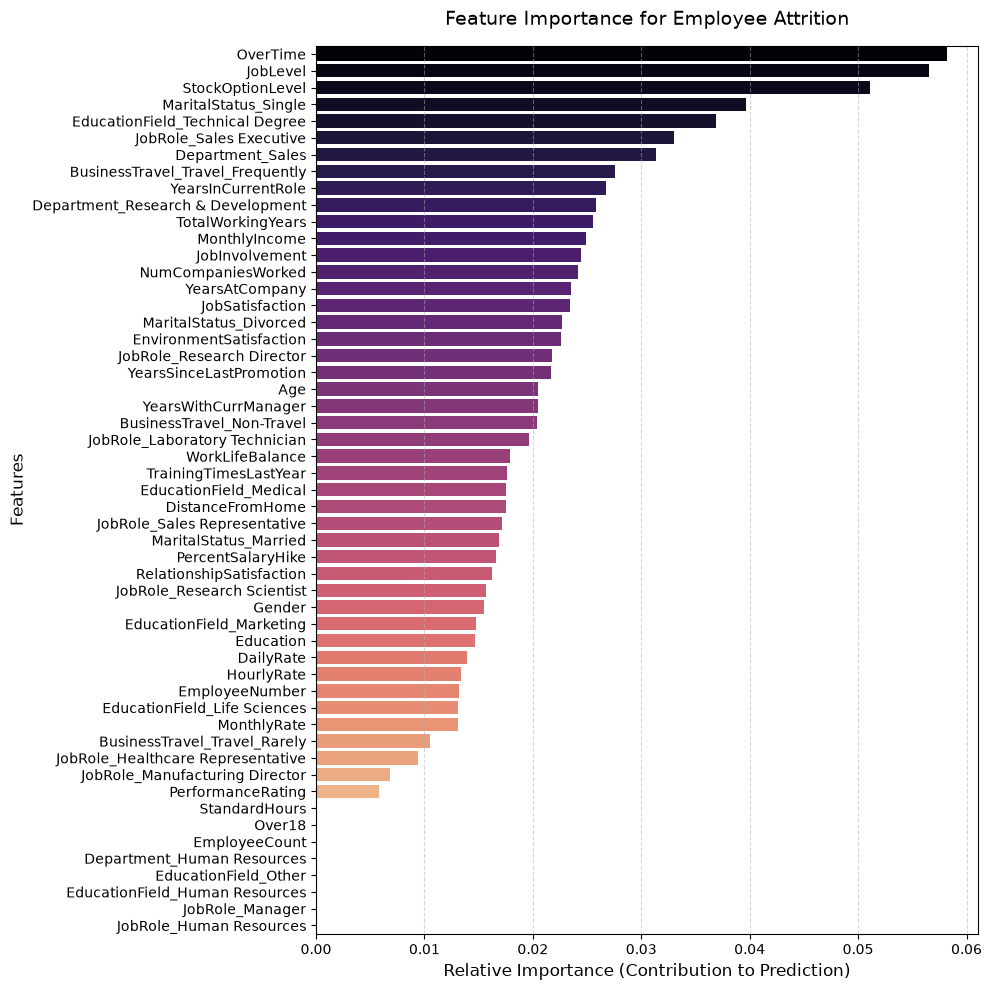

In [215]:
plot_feature_importance(xgb_model, X_train)

## 16. Visualization of model predictions

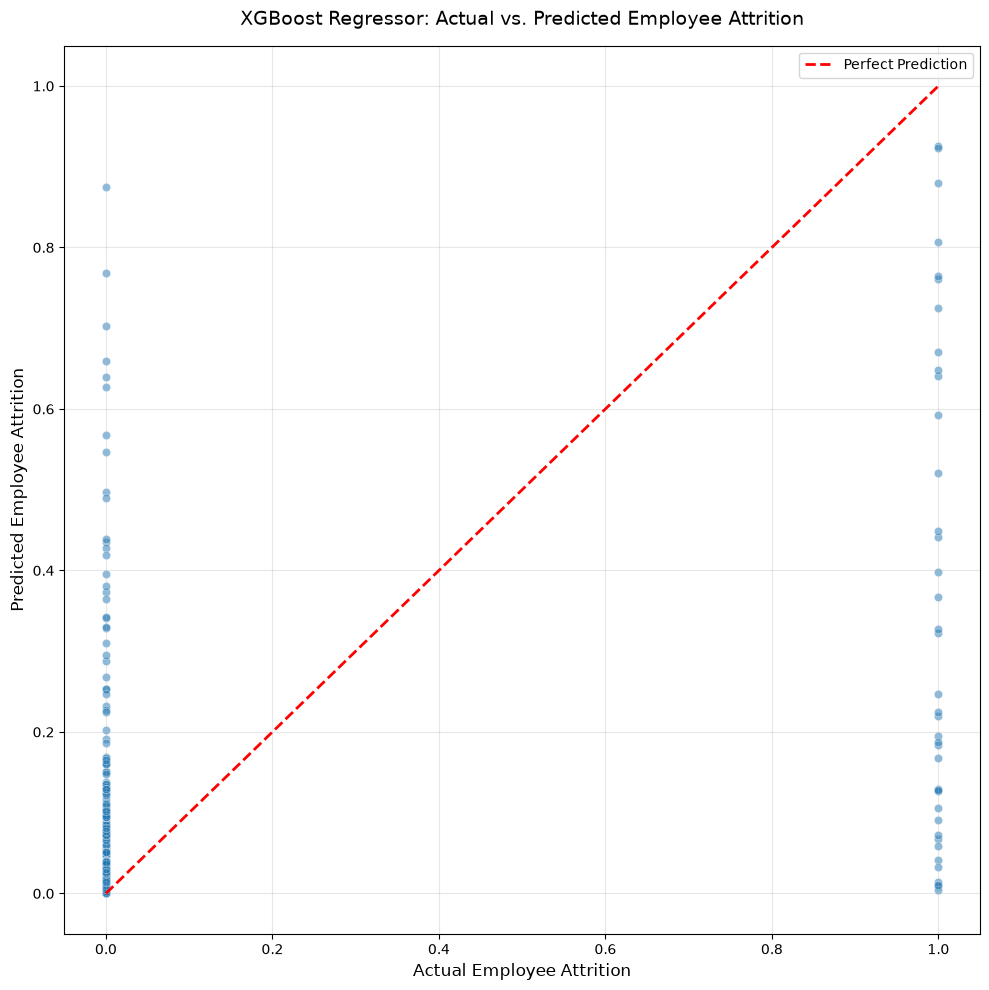

In [218]:
plot_predictions(y_test, y_pred_probablity)

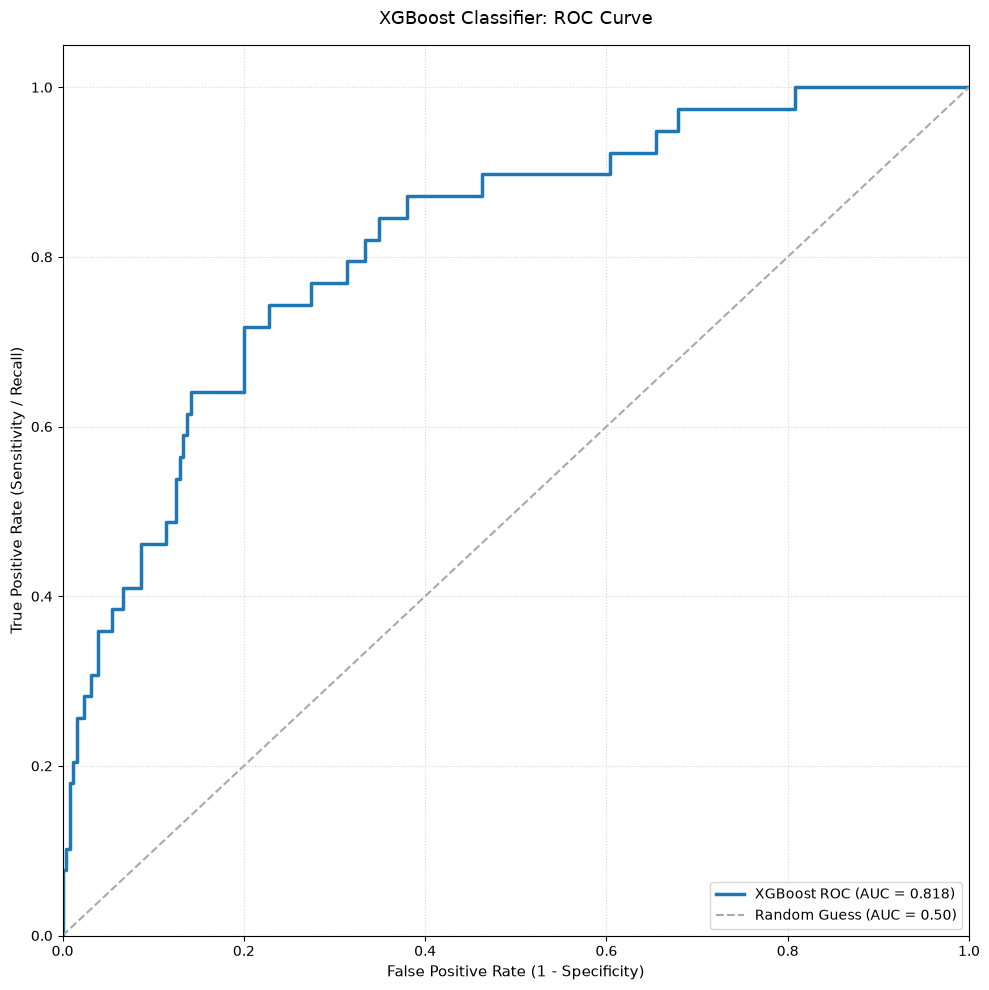

In [221]:
plot_roc_curve(y_test, y_pred_probablity)